<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: visualización de datos**

In [69]:
# Preámbulo ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [70]:
url = "https://raw.githubusercontent.com/chavezgranados/Quantitative-Methods/main/datasets/03titanic_tr.parquet"
datos = pd.read_parquet(url)
datos = datos.loc[:, :'FareGroup']
datos

,Survived,Pclass,Name,Sex,Age,HermanosConyuges,PadresHijos,Fare,LogFare,ViajaSolo,AgeGroup,FareGroup
0,no,Tercera,Mr. Owen Harris Braund,varon,22.0,1,0,7.2500,2.110213,no,adulto,economica
1,si,Primera,Mrs. John Bradley (Florence Briggs Thayer) Cum...,mujer,38.0,1,0,71.2833,4.280593,no,adulto,alta
2,si,Tercera,Miss. Laina Heikkinen,mujer,26.0,0,0,7.9250,2.188856,si,adulto,economica
3,si,Primera,Mrs. Jacques Heath (Lily May Peel) Futrelle,mujer,35.0,1,0,53.1000,3.990834,no,adulto,alta
4,no,Tercera,Mr. William Henry Allen,varon,35.0,0,0,8.0500,2.202765,si,adulto,economica
...,...,...,...,...,...,...,...,...,...,...,...,...
882,no,Segunda,Rev. Juozas Montvila,varon,27.0,0,0,13.0000,2.639057,si,adulto,media
883,si,Primera,Miss. Margaret Edith Graham,mujer,19.0,0,0,30.0000,3.433987,si,adulto,media
884,no,Tercera,Miss. Catherine Helen Johnston,mujer,7.0,1,2,23.4500,3.196630,no,infante,media
885,si,Primera,Mr. Karl Howell Behr,varon,26.0,0,0,30.0000,3.433987,si,adulto,media


In [71]:
# Tema para gráficos
# ==============================================================================
sns.set_theme(style="white", context="paper", palette="colorblind", font_scale=1.2)
plt.rcParams.update({
    "figure.figsize": (7, 5),
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "grid.alpha": 0.25,
    "grid.linestyle": "--"
})

## **1.1 Gráficos univariados**

**a) Variables cualitativas**

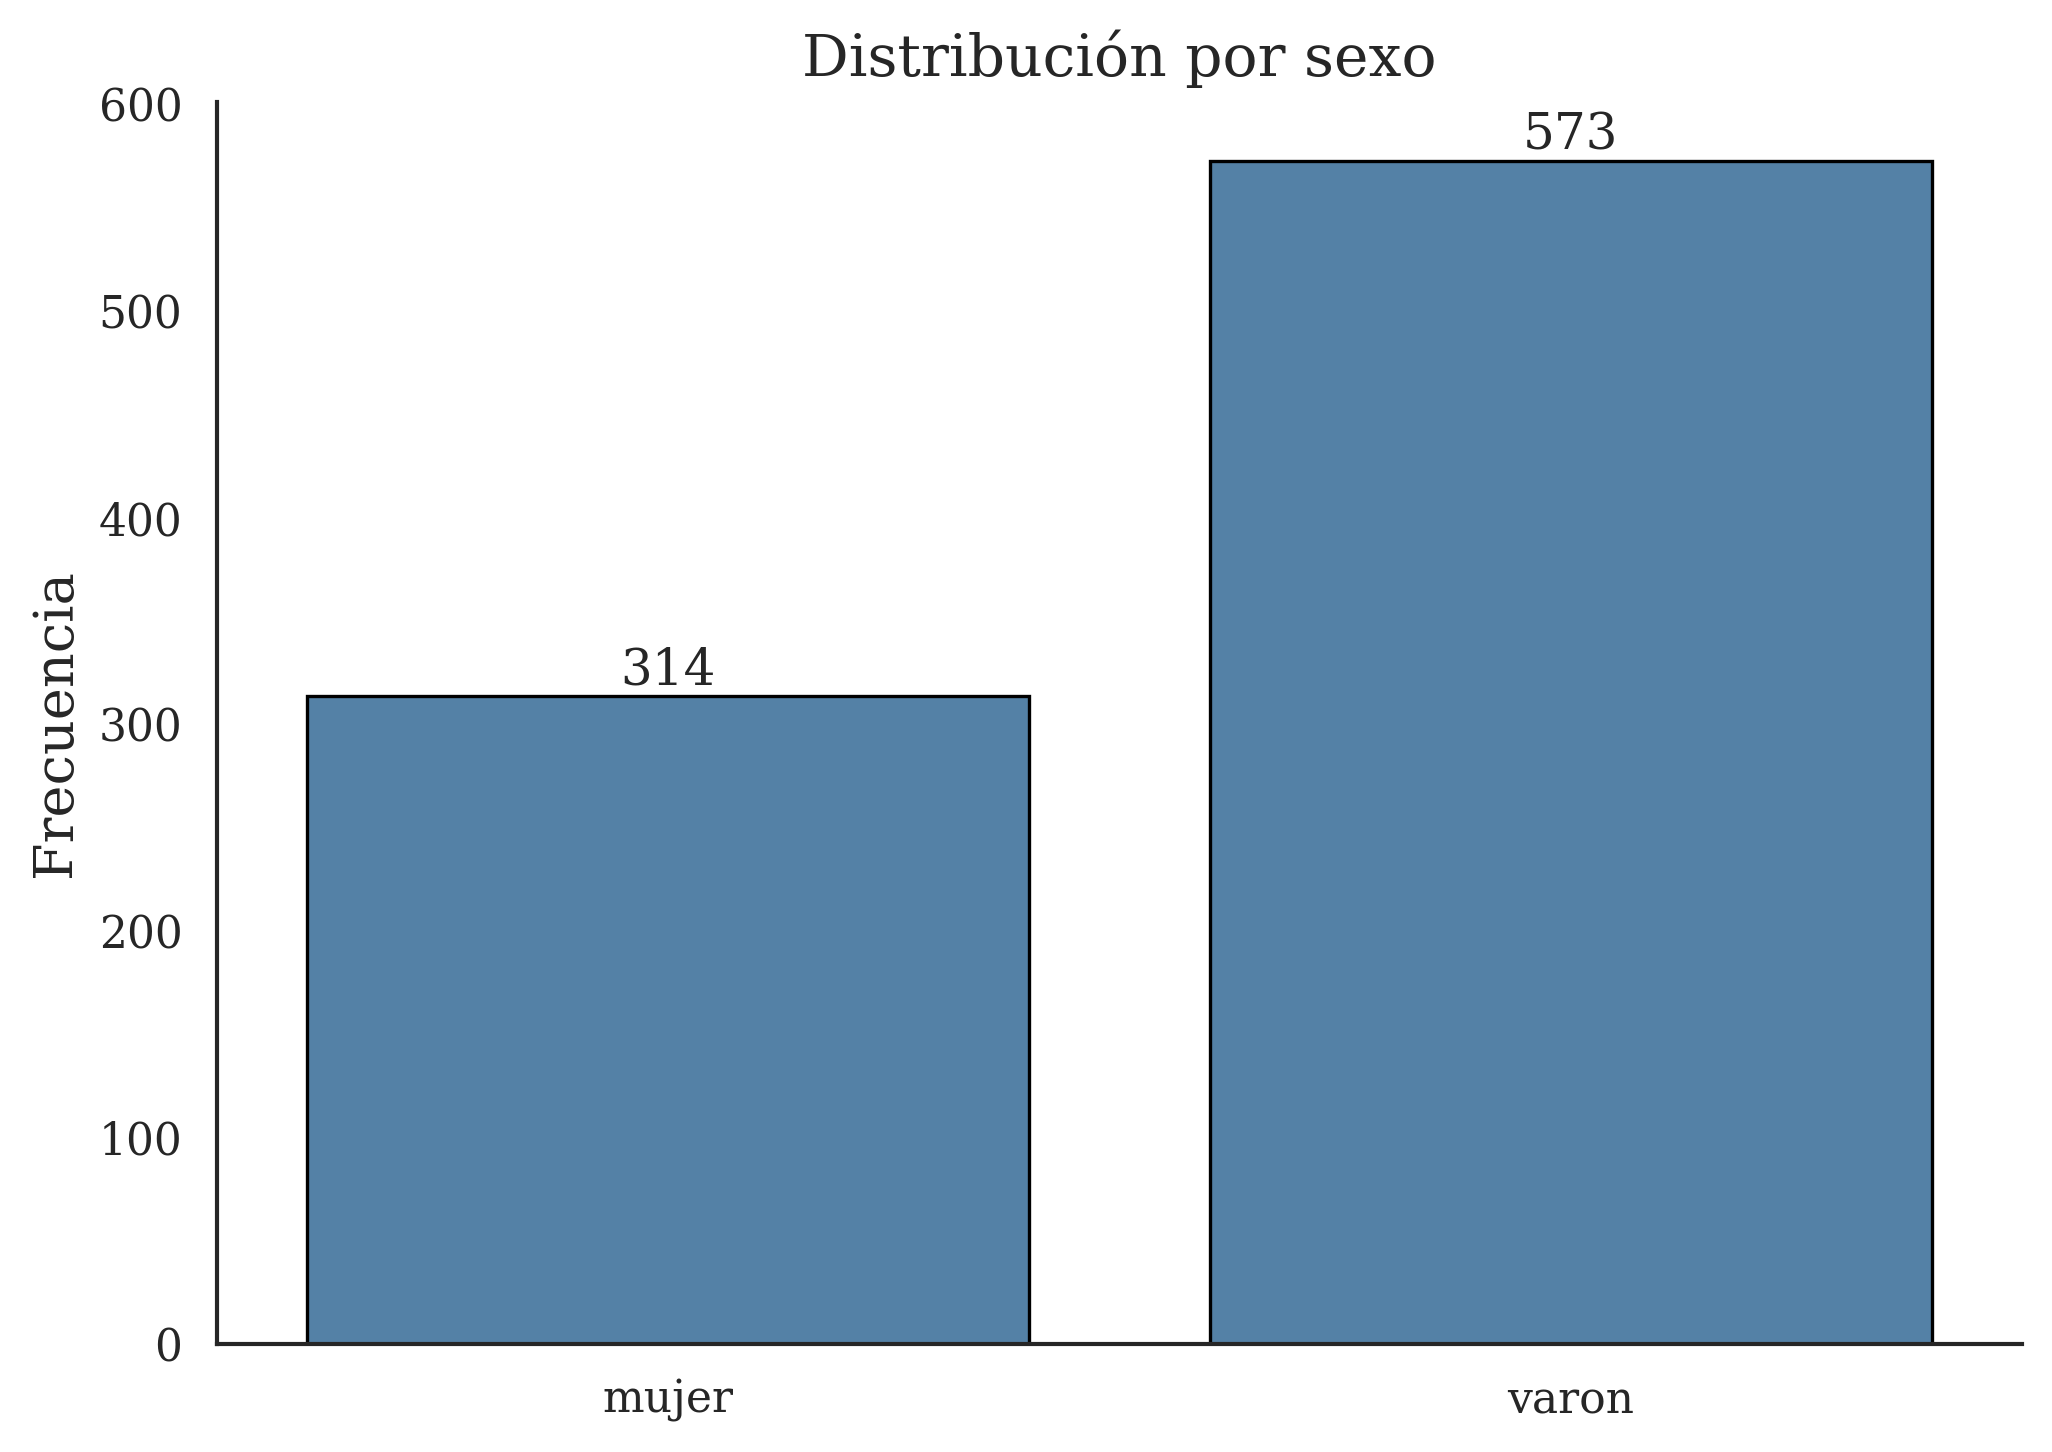

In [72]:
# Gráficos de barras
fig, ax = plt.subplots()

sns.countplot(data=datos, x="Sex", color="steelblue", edgecolor="black", linewidth=0.8, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución por sexo")
for container in ax.containers:
    ax.bar_label(container)
sns.despine()
plt.tight_layout()
plt.show()

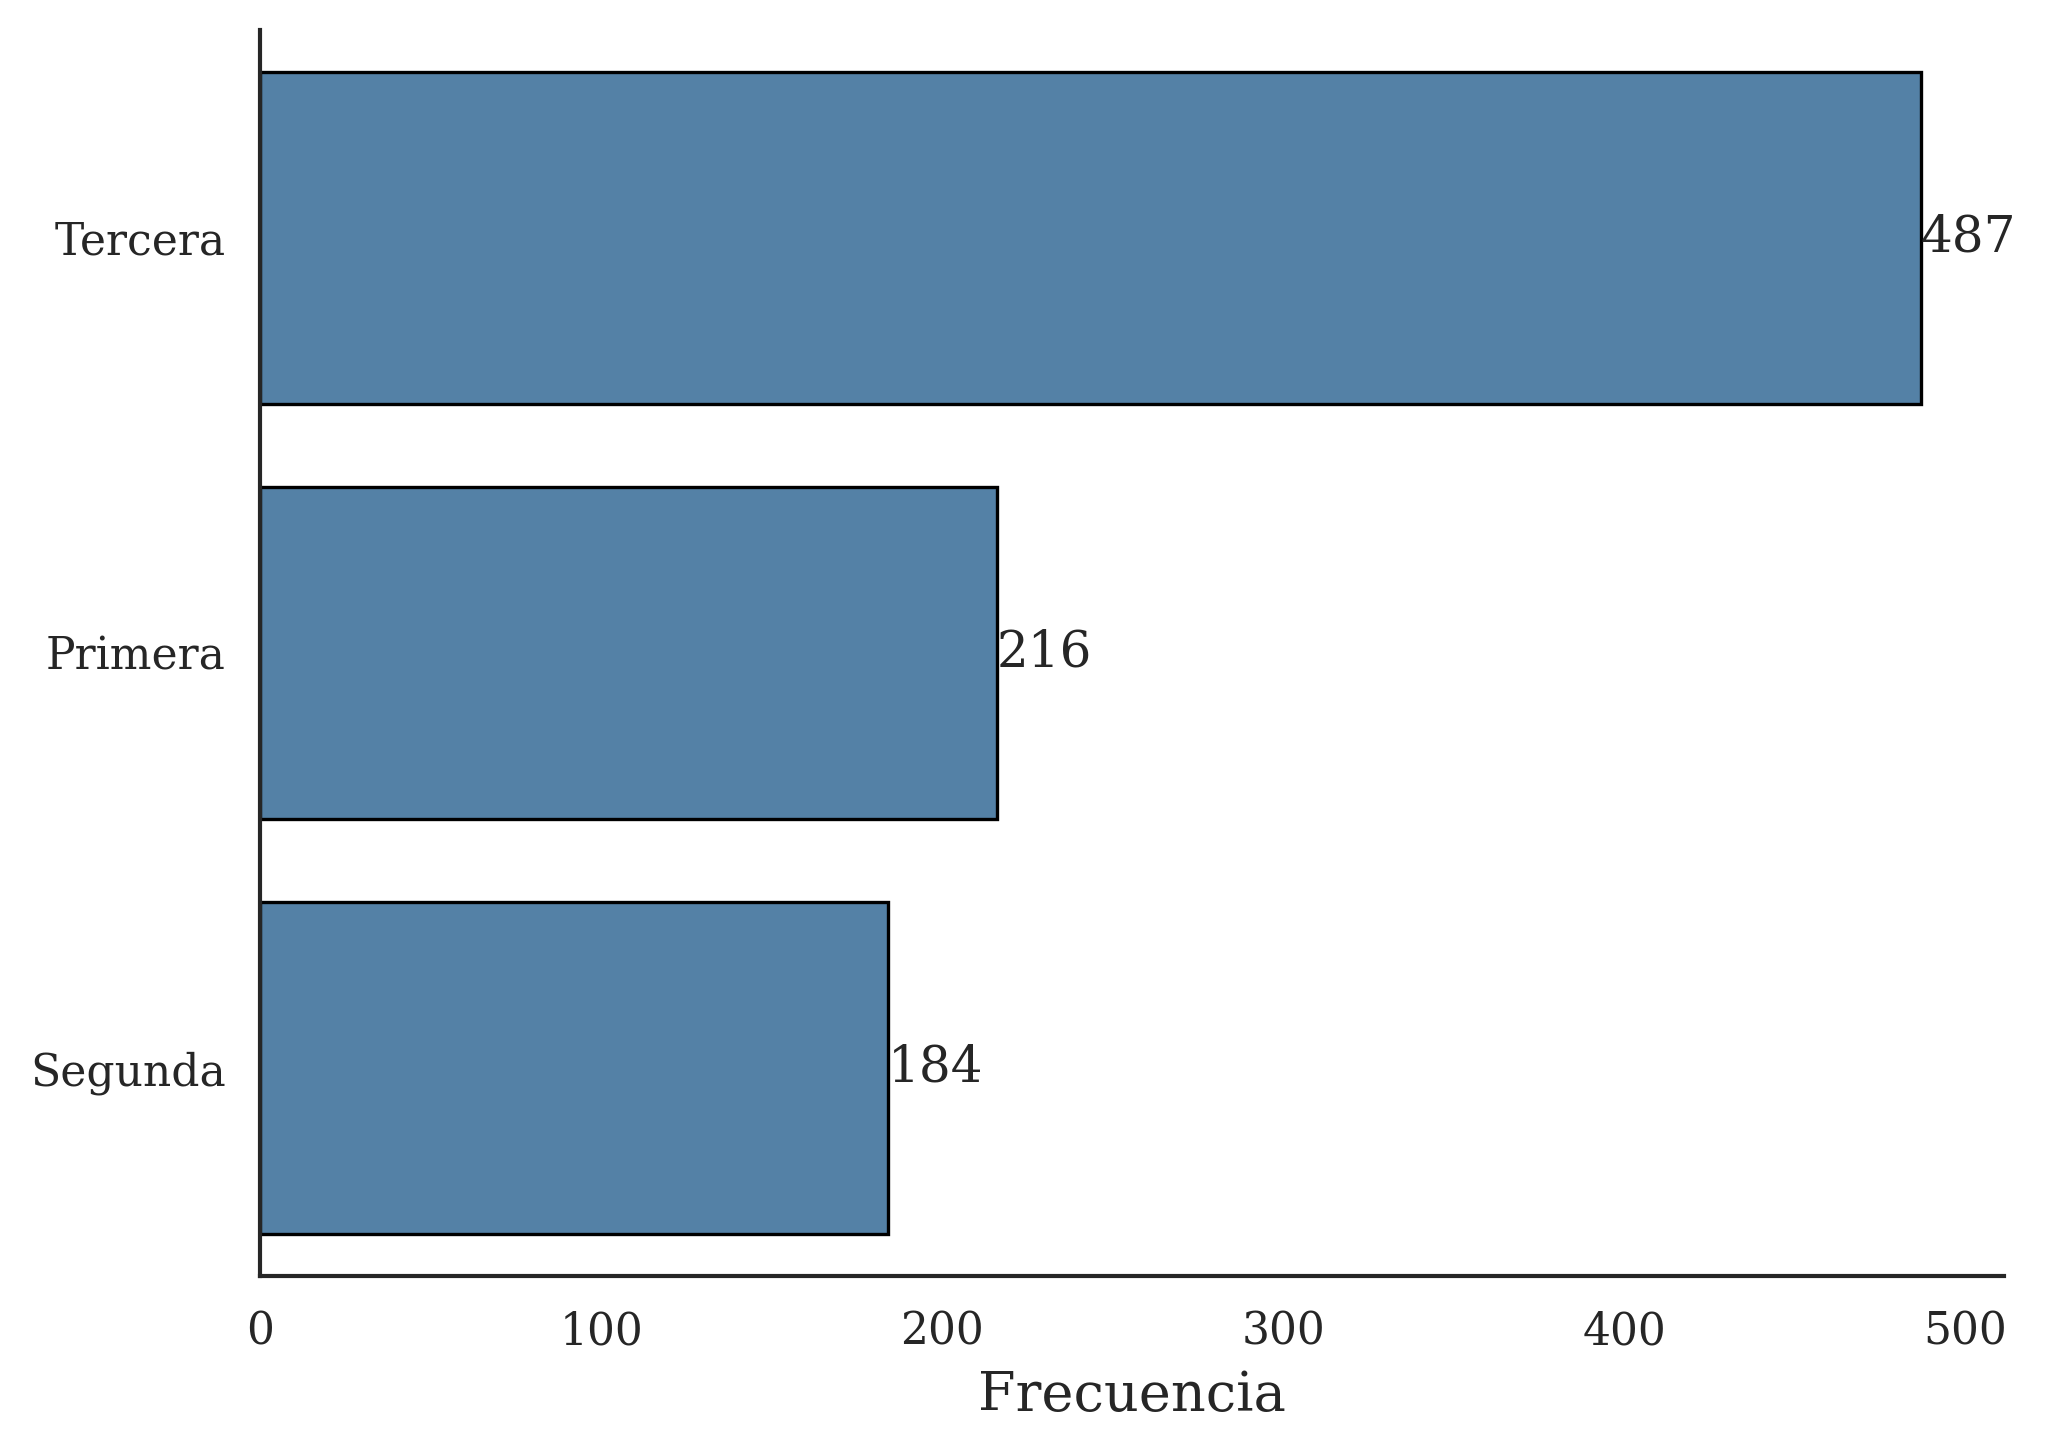

In [73]:
# Gráficos de barras horizontal
orden = datos["Pclass"].value_counts().index
fig, ax = plt.subplots()
sns.countplot(data=datos, y="Pclass", order=orden, color="steelblue", edgecolor="black", linewidth=0.8, ax=ax)
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container)
sns.despine()
plt.tight_layout()
plt.show()

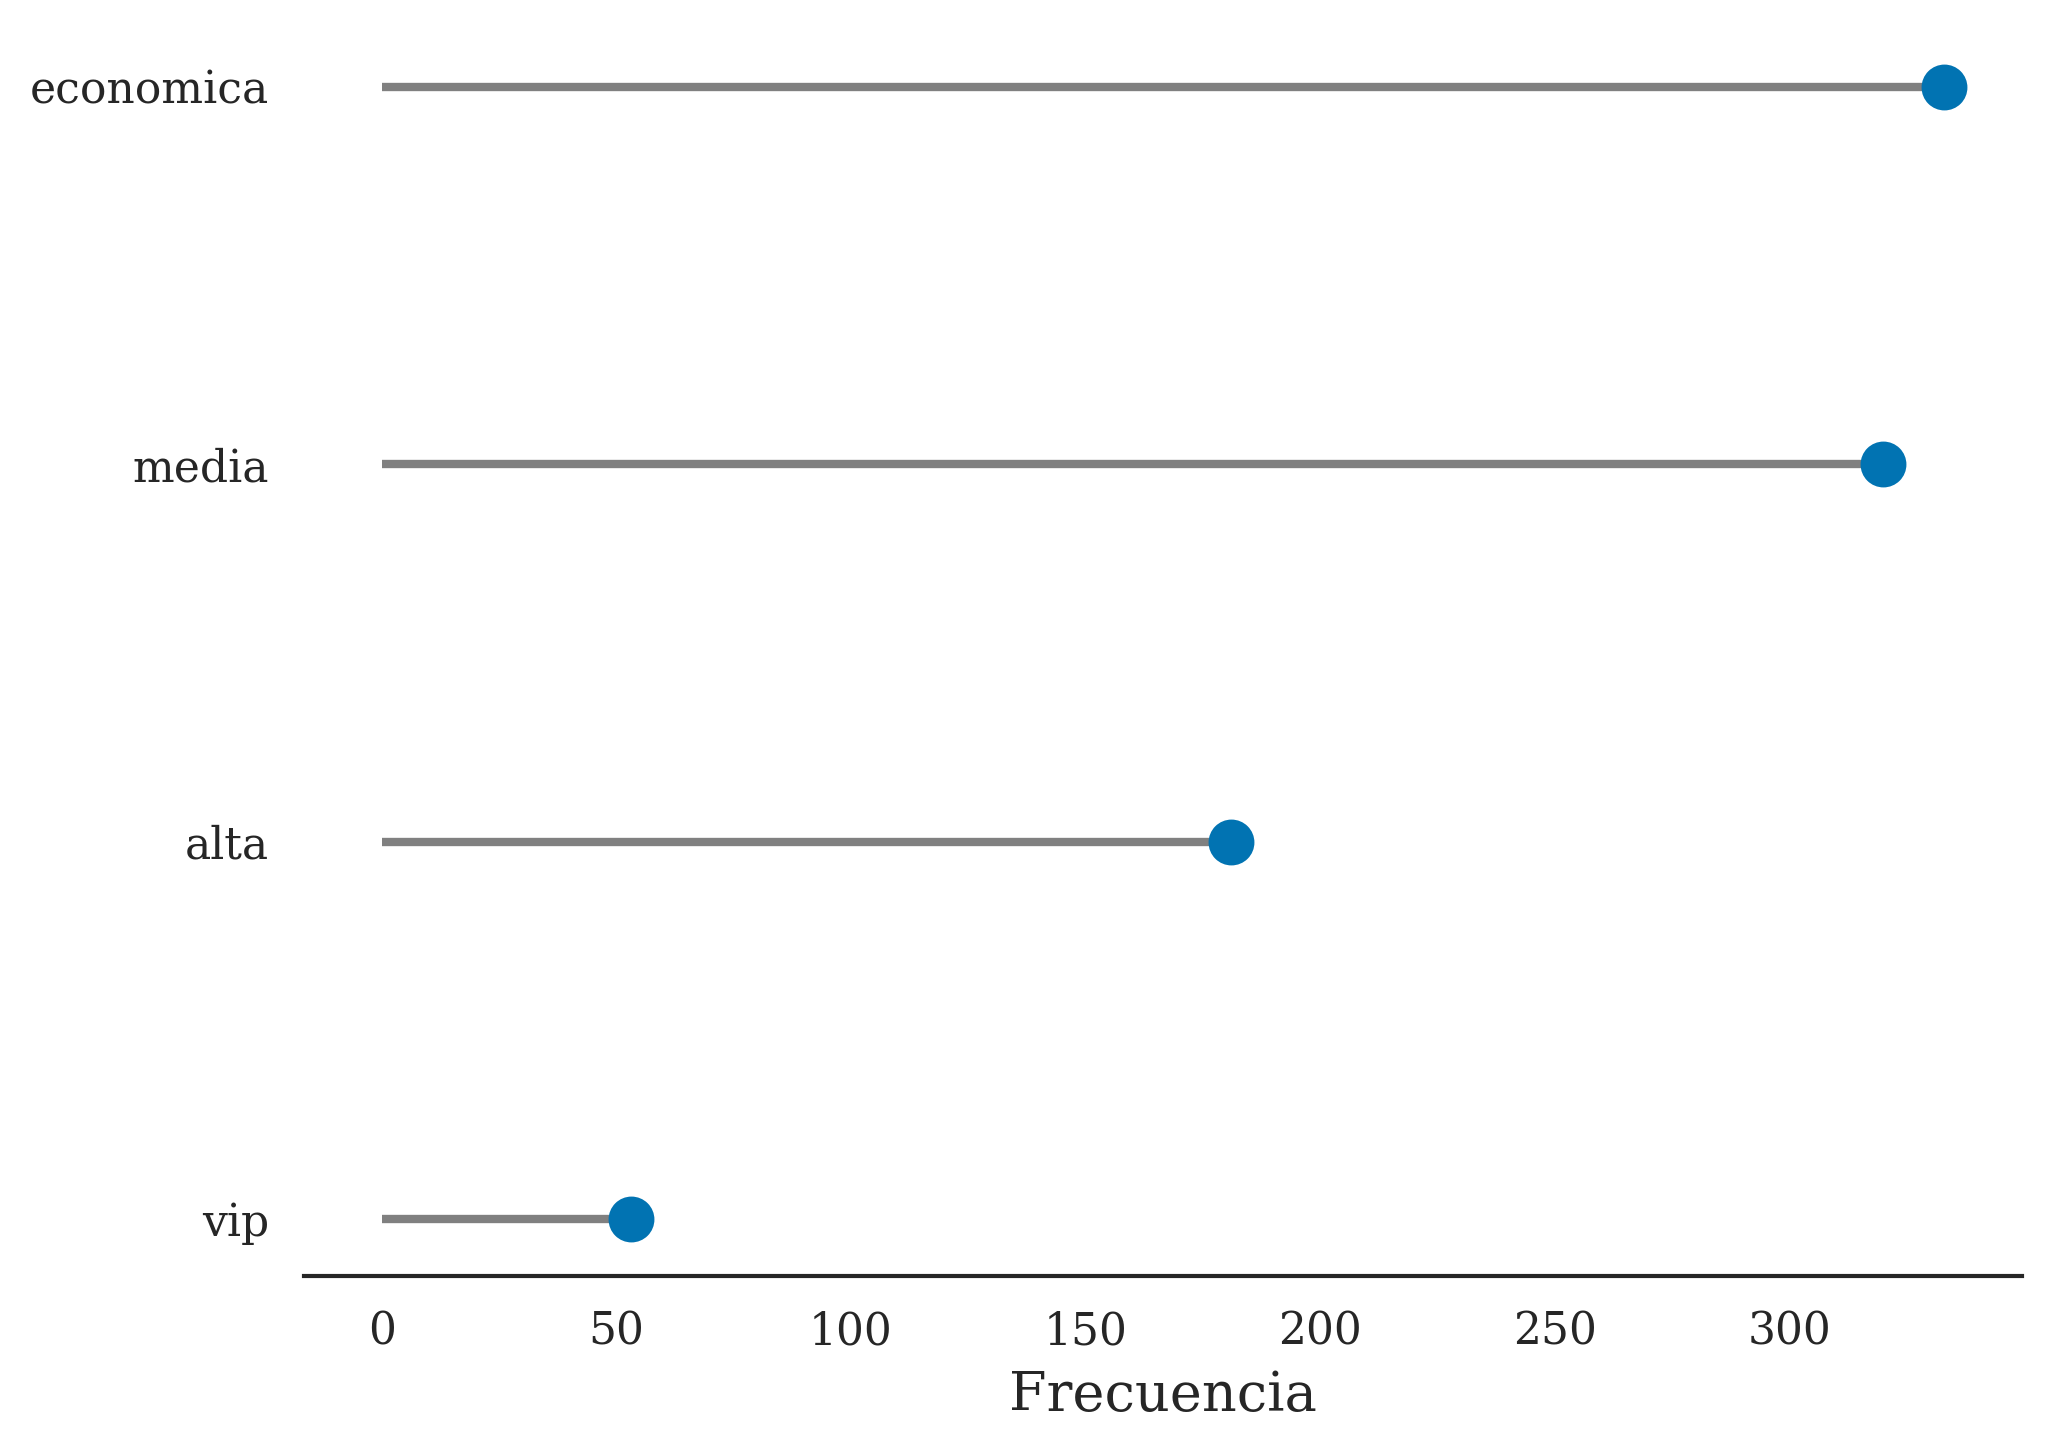

In [74]:
# Lollipop Chart
conteo = datos["FareGroup"].value_counts().sort_values()
fig, ax = plt.subplots()
ax.hlines(y=conteo.index,
    xmin=0,
    xmax=conteo.values,
    color="gray",
    linewidth=2)
ax.plot(conteo.values,
    conteo.index,
    "o",
    markersize=10)
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(left=True)
plt.tight_layout()

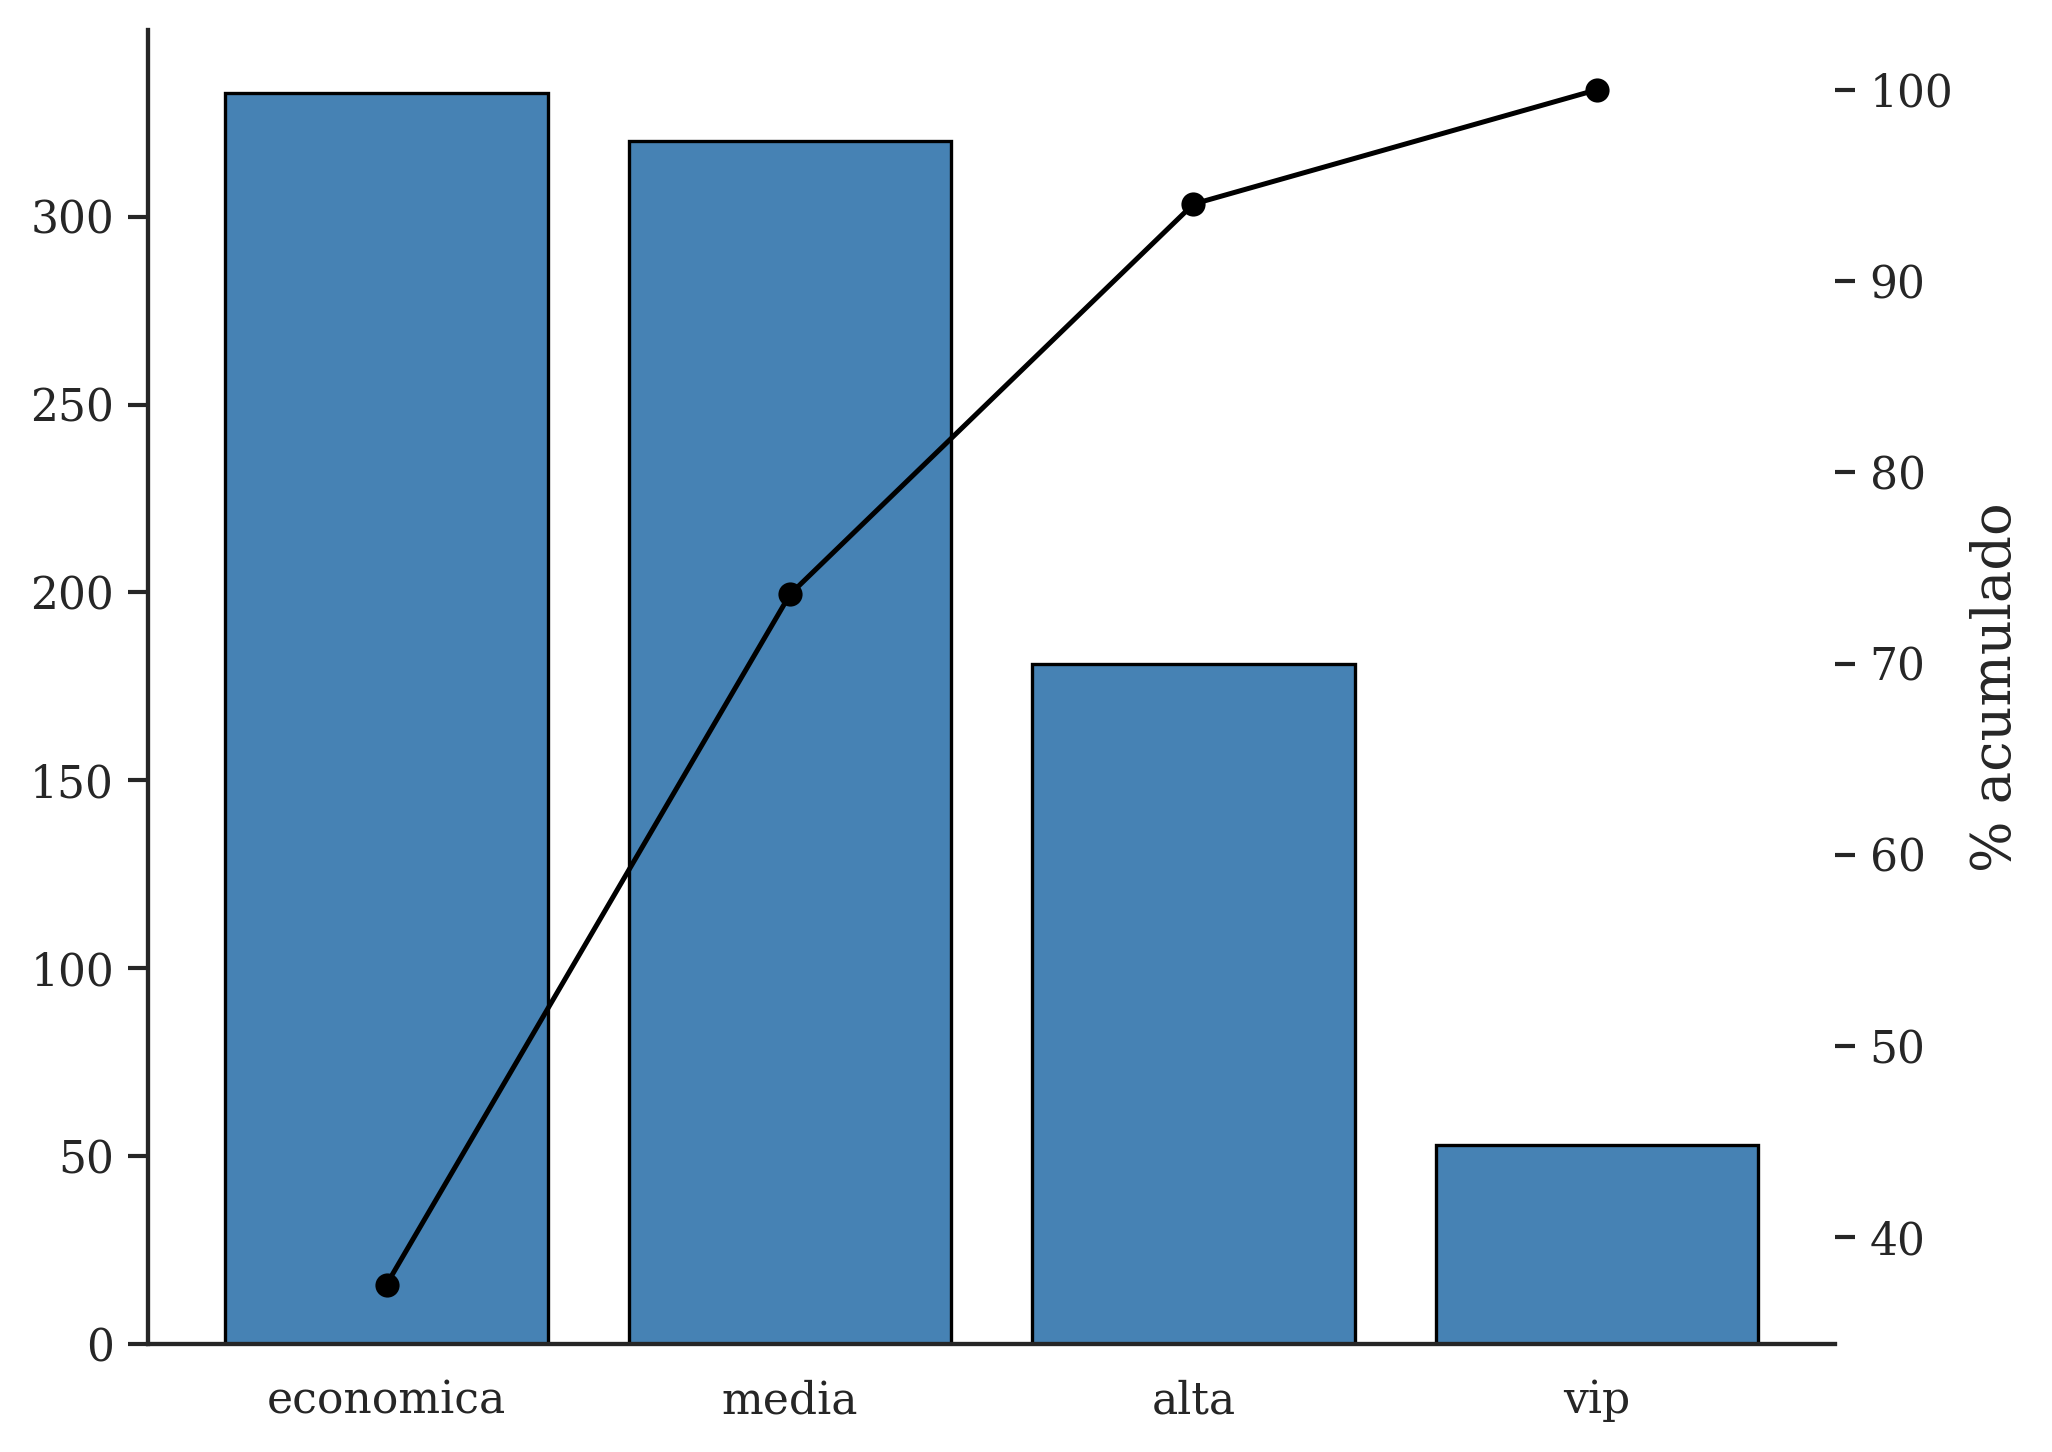

In [75]:
# Pareto
conteo = datos["FareGroup"].value_counts()
pareto = conteo.sort_values(ascending=False)
acum = pareto.cumsum()/pareto.sum()*100
fig, ax1 = plt.subplots()
ax1.bar(pareto.index,
    pareto.values,
    color="steelblue",
    edgecolor="black")
ax2 = ax1.twinx()
ax2.plot(pareto.index,
    acum,
    color="black",
    marker="o")
ax2.set_ylabel("% acumulado")
plt.tight_layout()

**b) Variables cuantitativas**

<Axes: xlabel='Age', ylabel='Count'>

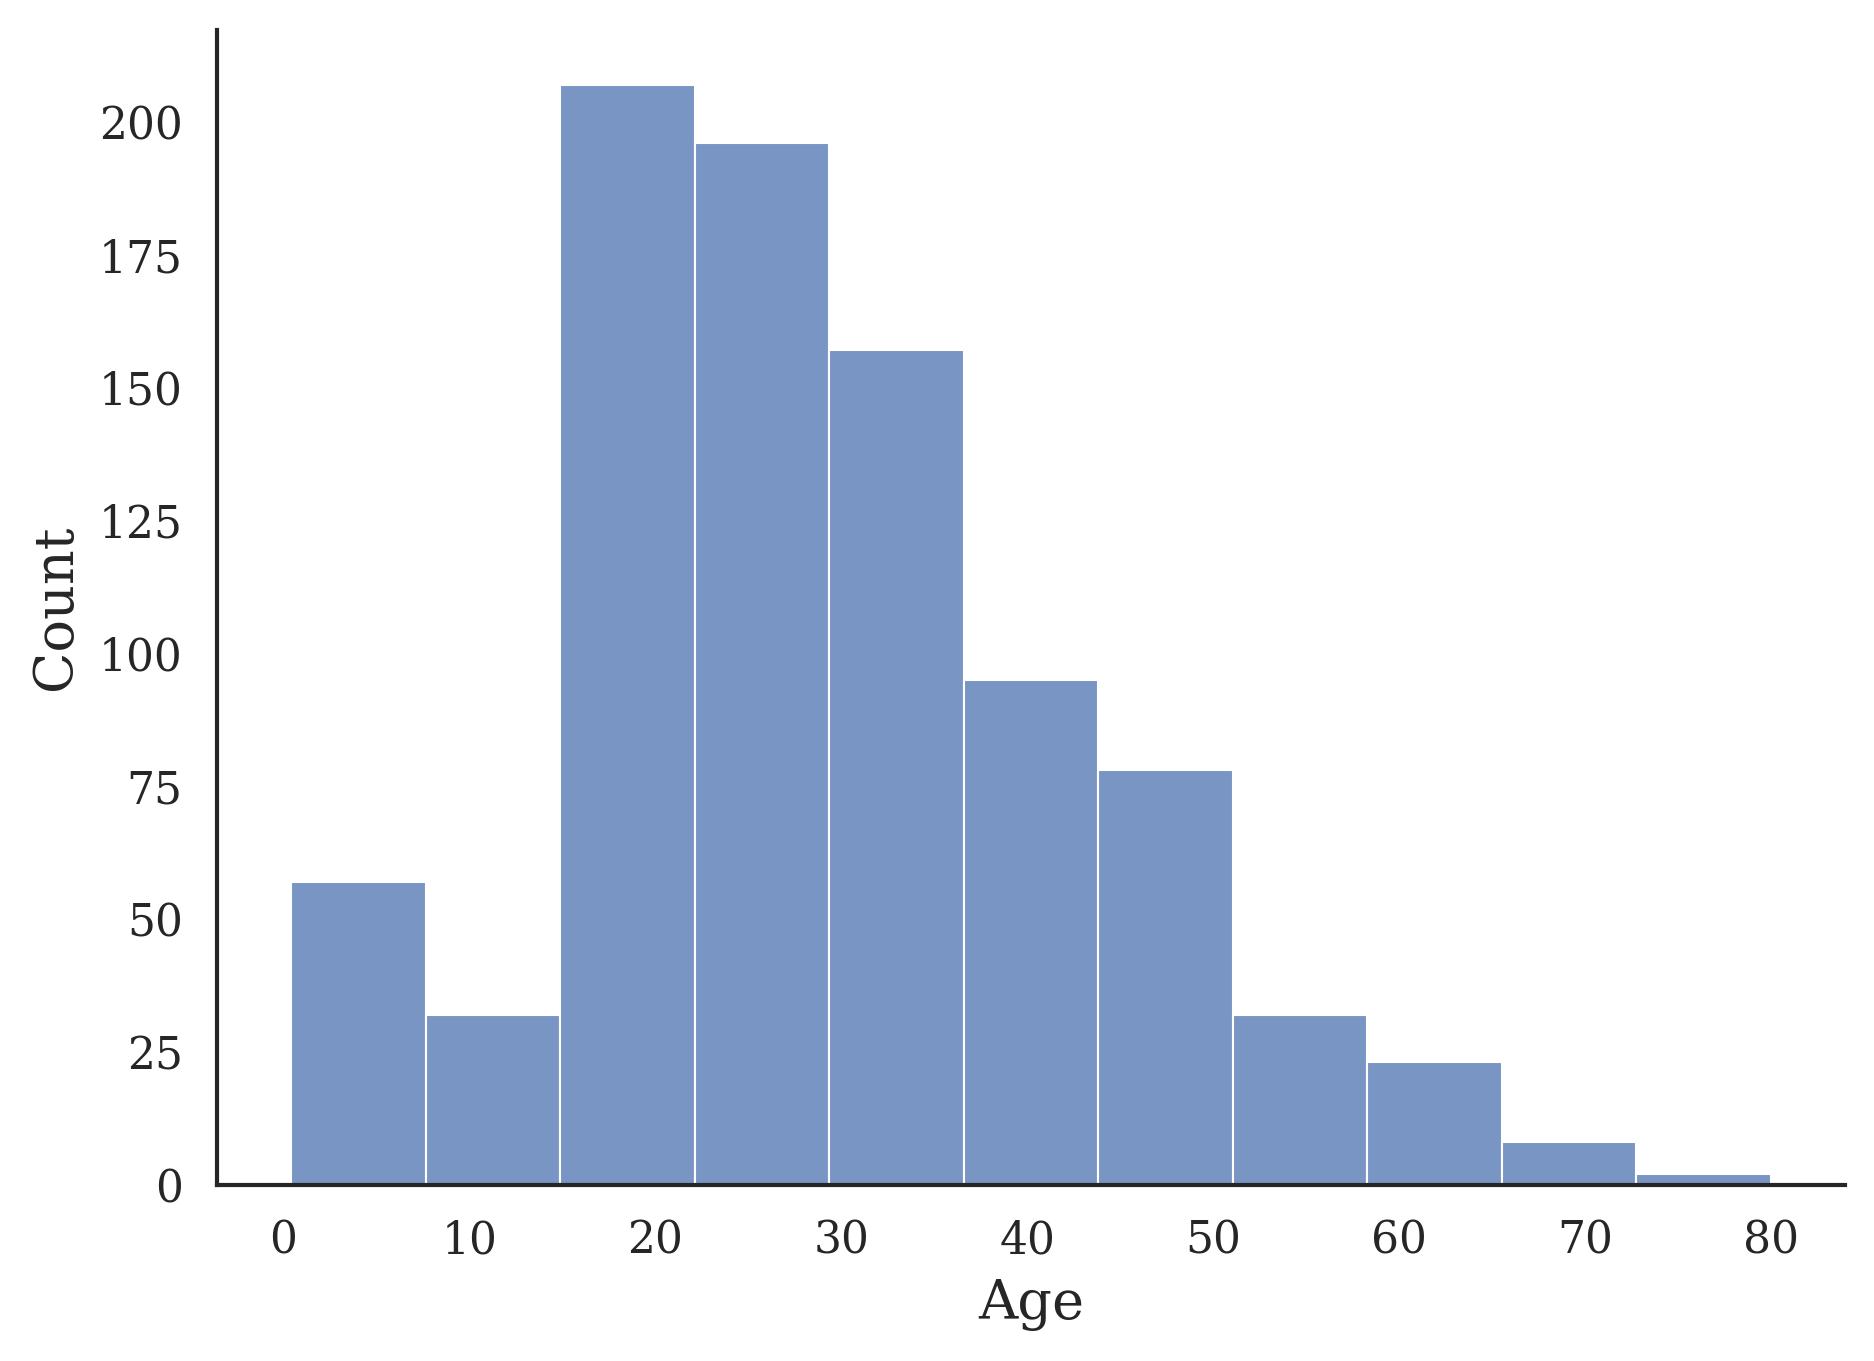

In [76]:
# Histograma
sns.histplot(data=datos, x="Age", bins="sturges", color="#4C72B0", edgecolor="white", linewidth=.5)

<Axes: xlabel='Age', ylabel='Count'>

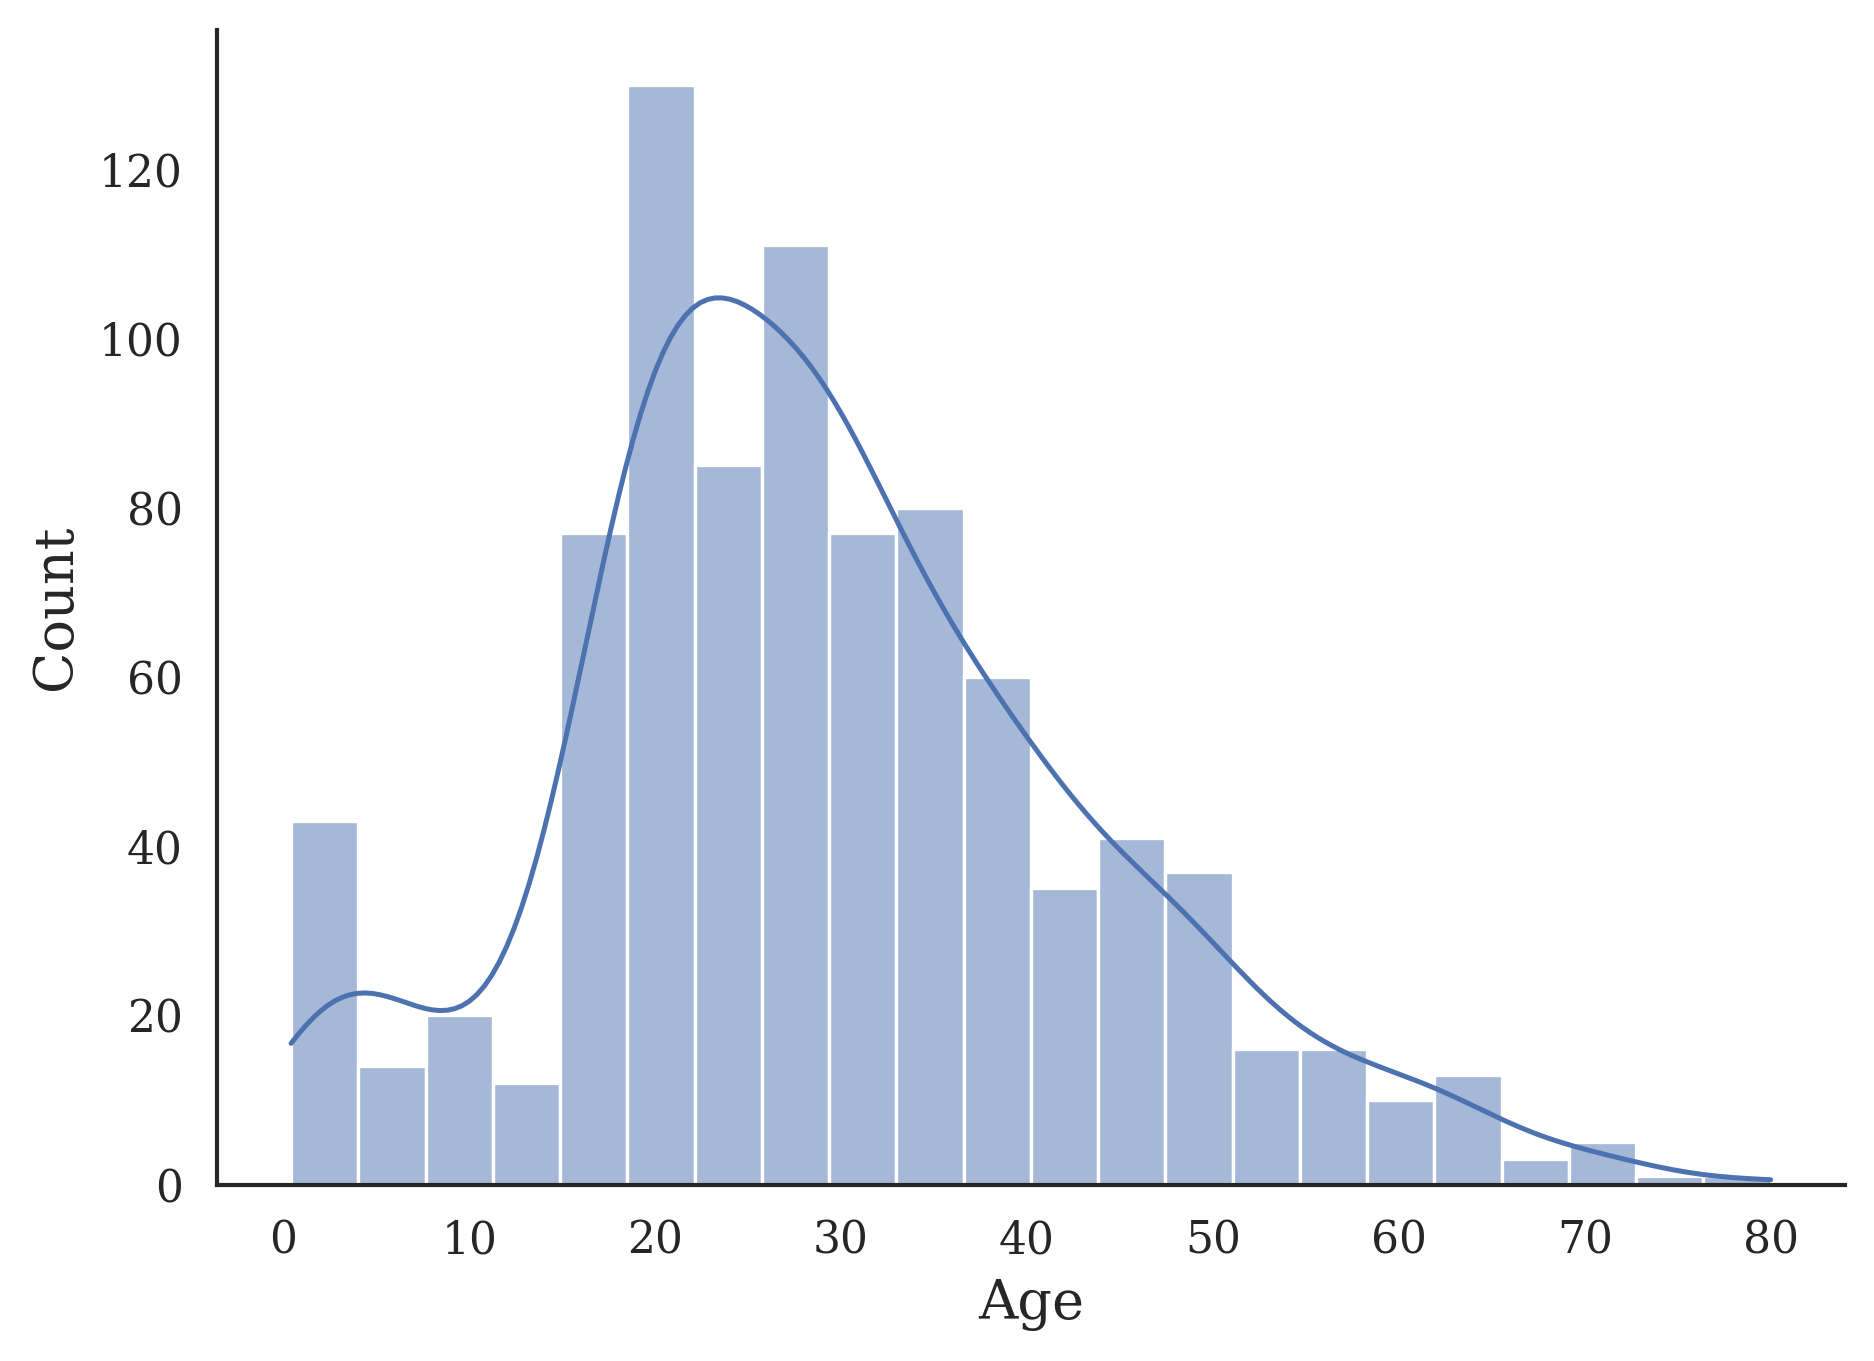

In [77]:
# Histograma + densidad
sns.histplot(data=datos, x="Age", kde=True, color="#4C72B0", edgecolor="white")

## **1.2 Gráficos bivariados**

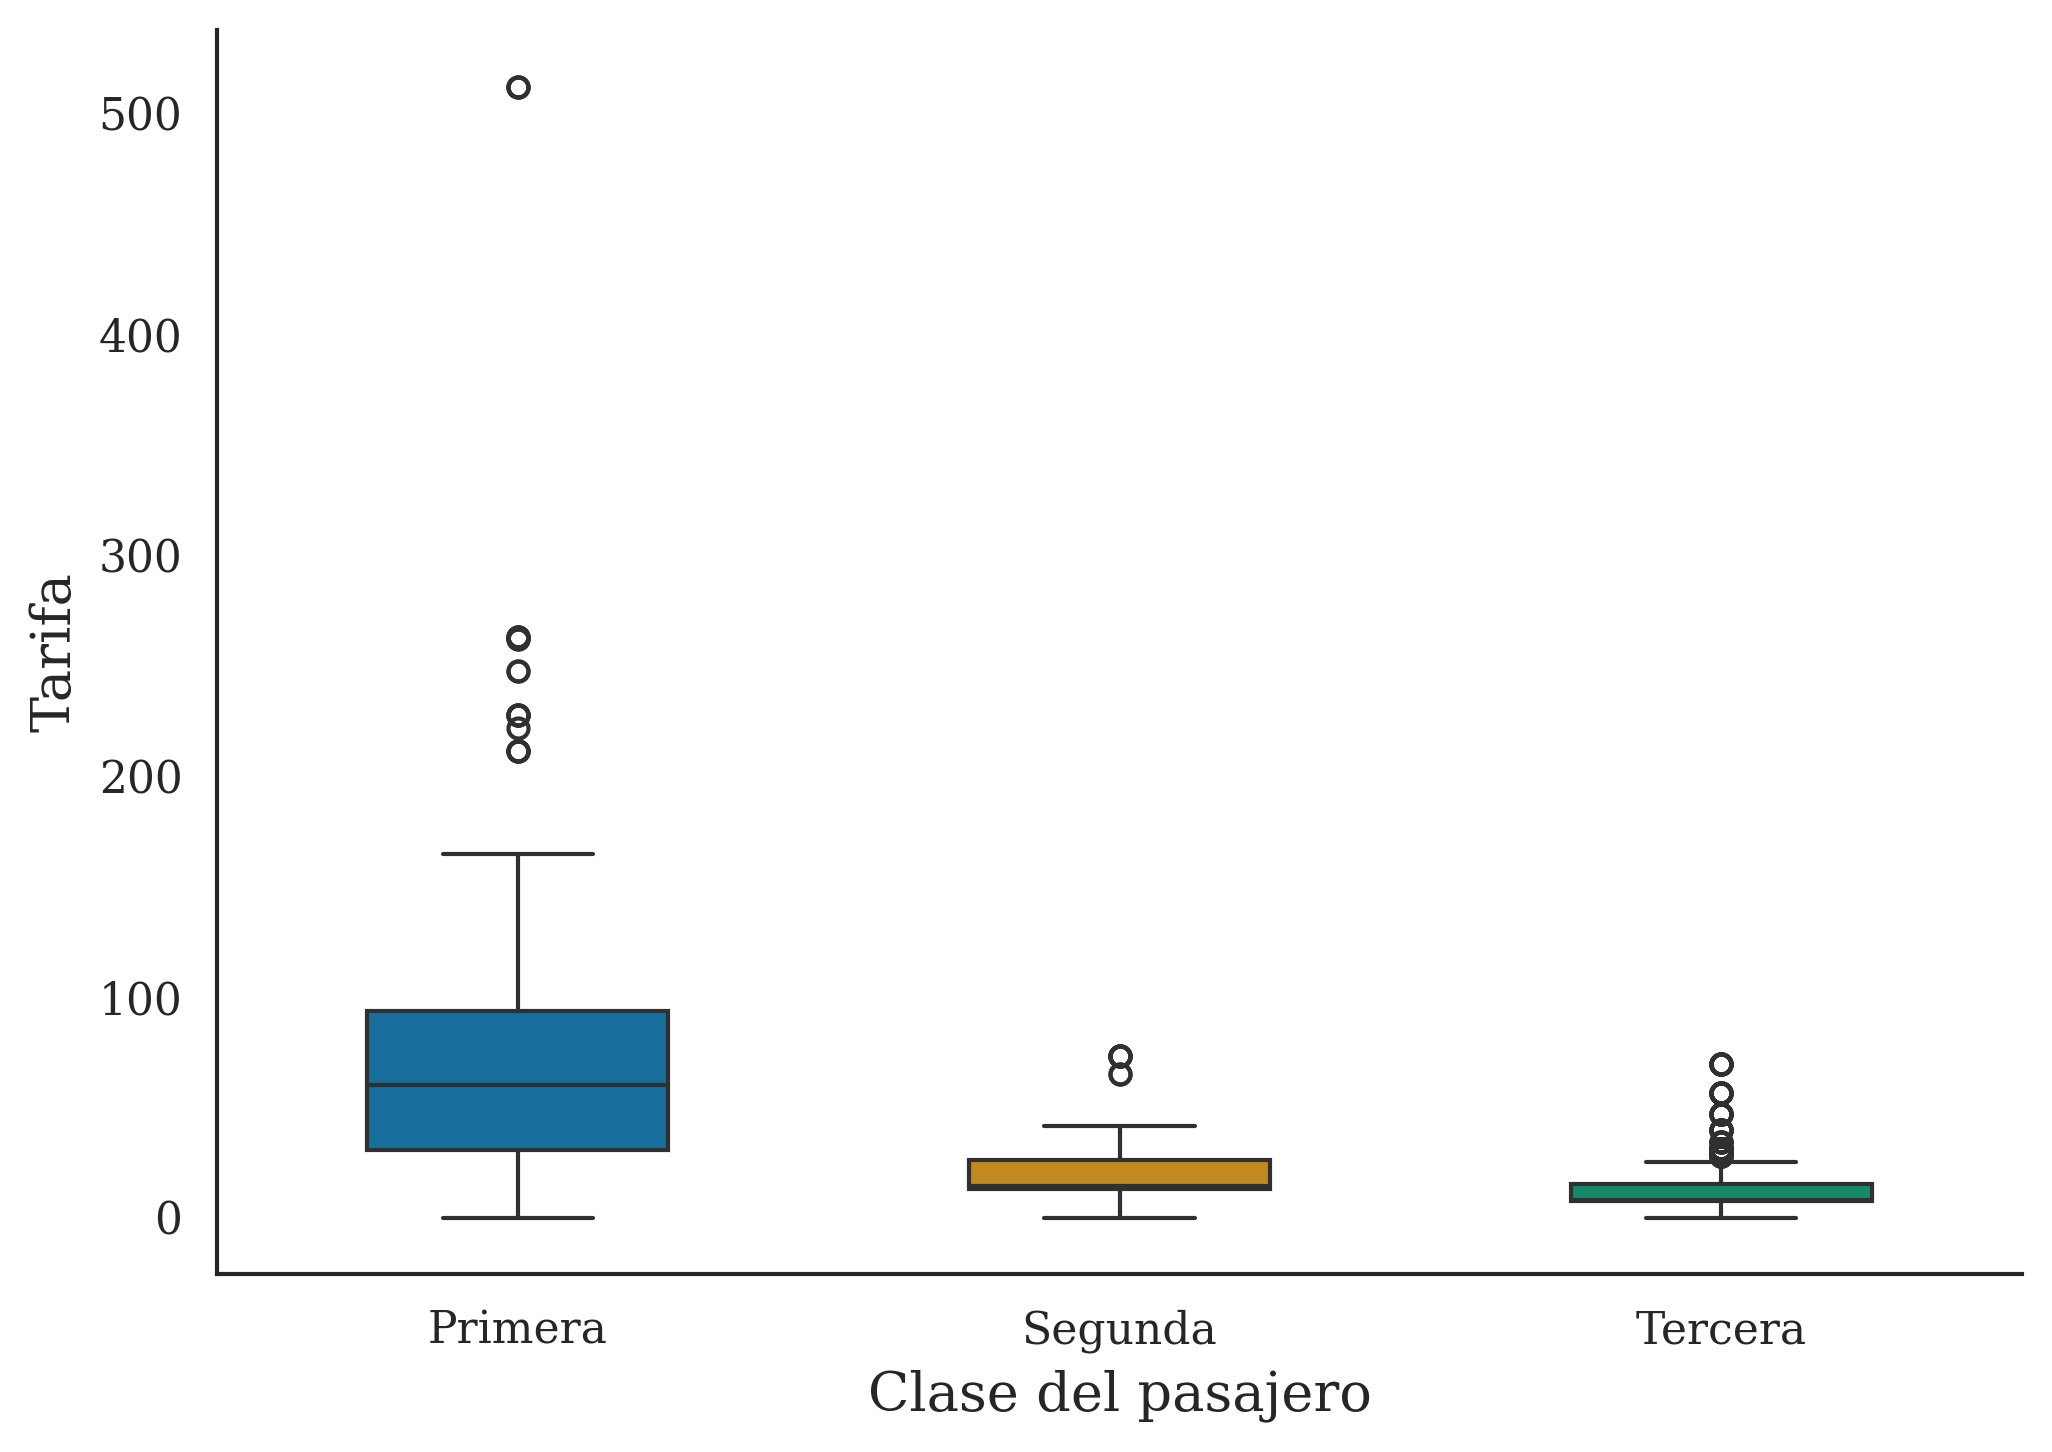

In [78]:
# Diagrama de caja
plt.figure(figsize=(7,5))
sns.boxplot(data=datos,
    x="Pclass",
    y="Fare",
    hue="Pclass",
    palette="colorblind",
    dodge=False,
    width=0.5,
    legend=False)
plt.xlabel("Clase del pasajero")
plt.ylabel("Tarifa")
sns.despine()
plt.tight_layout()
plt.show()

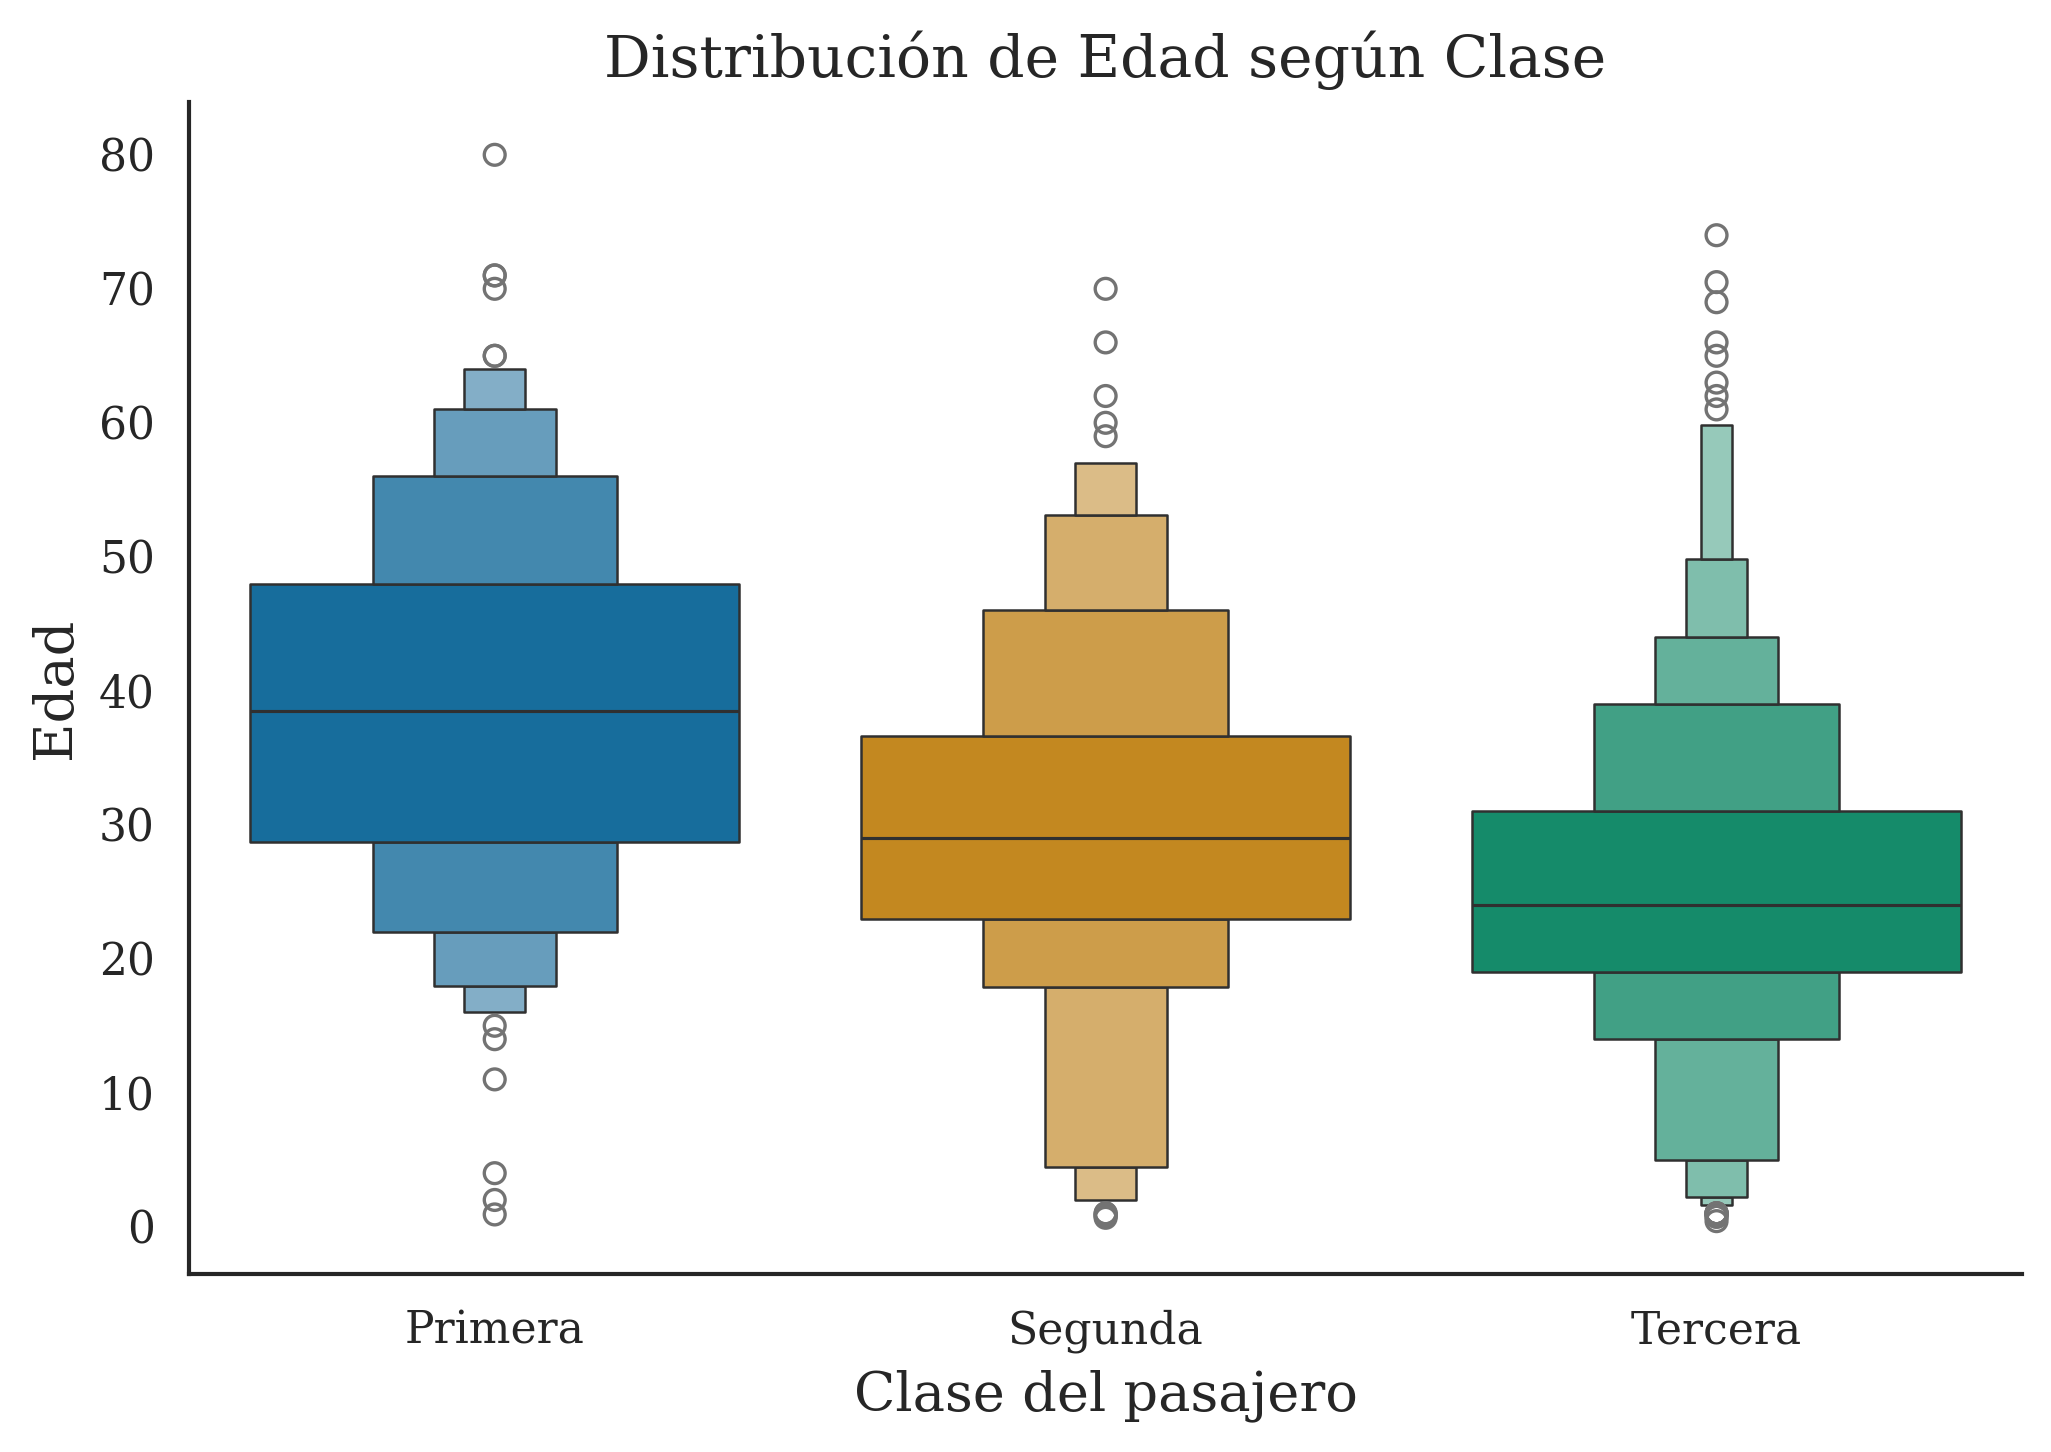

In [79]:
# Boxen Plot
plt.figure(figsize=(7,5))
sns.boxenplot(data=datos,
    x="Pclass",
    y="Age",
    hue="Pclass",
    palette="colorblind",
    legend=False)
plt.xlabel("Clase del pasajero")
plt.ylabel("Edad")
plt.title("Distribución de Edad según Clase")
sns.despine()
plt.tight_layout()
plt.show()

<Axes: xlabel='Survived', ylabel='LogFare'>

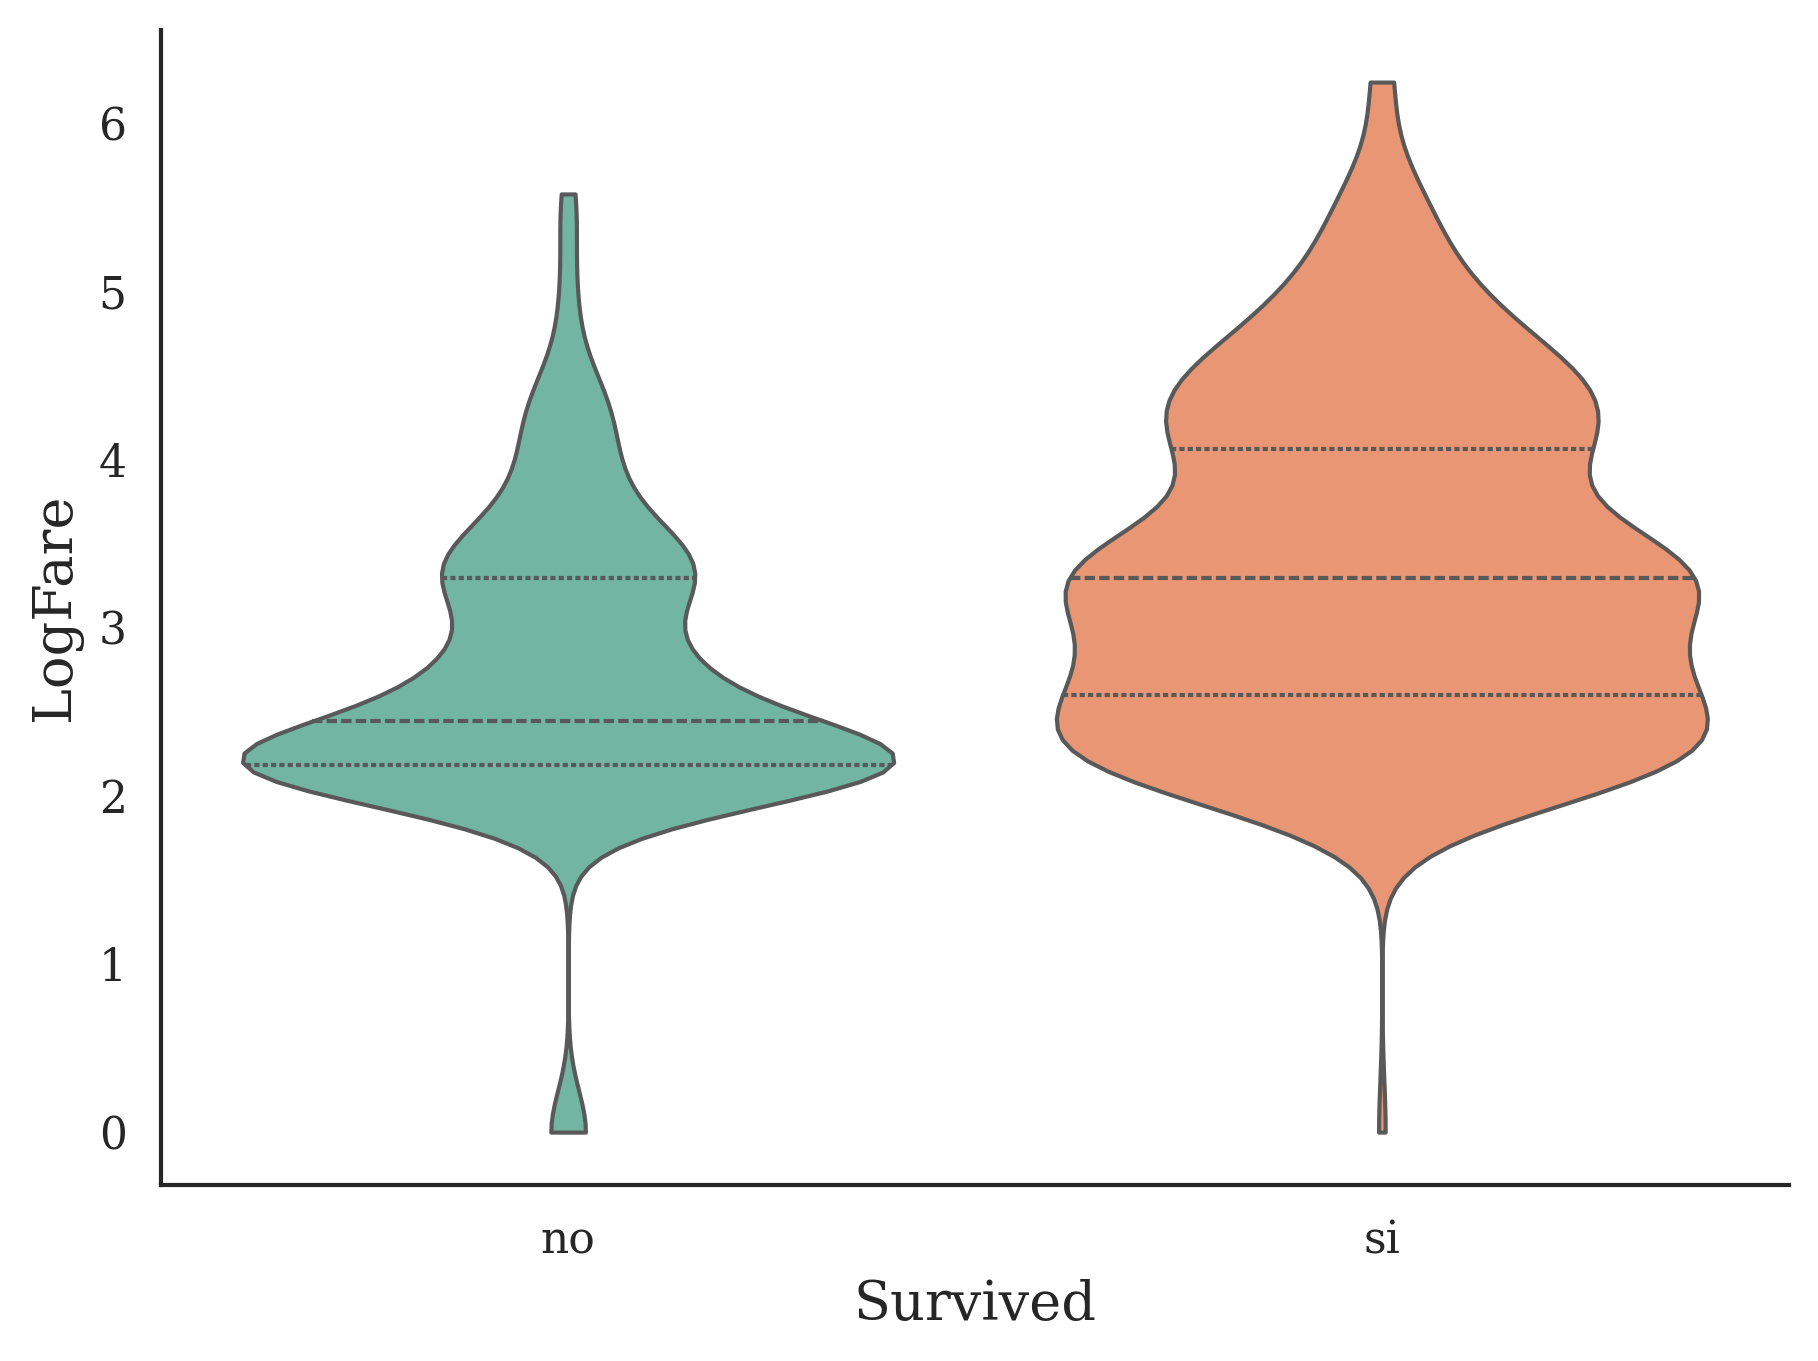

In [80]:
# Violín
sns.violinplot(data=datos,
    x="Survived",
    y="LogFare",
    hue="Survived",
    palette="Set2",
    legend=False,
    inner="quartile",
    cut=0)

In [81]:
pip install ptitprince

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):


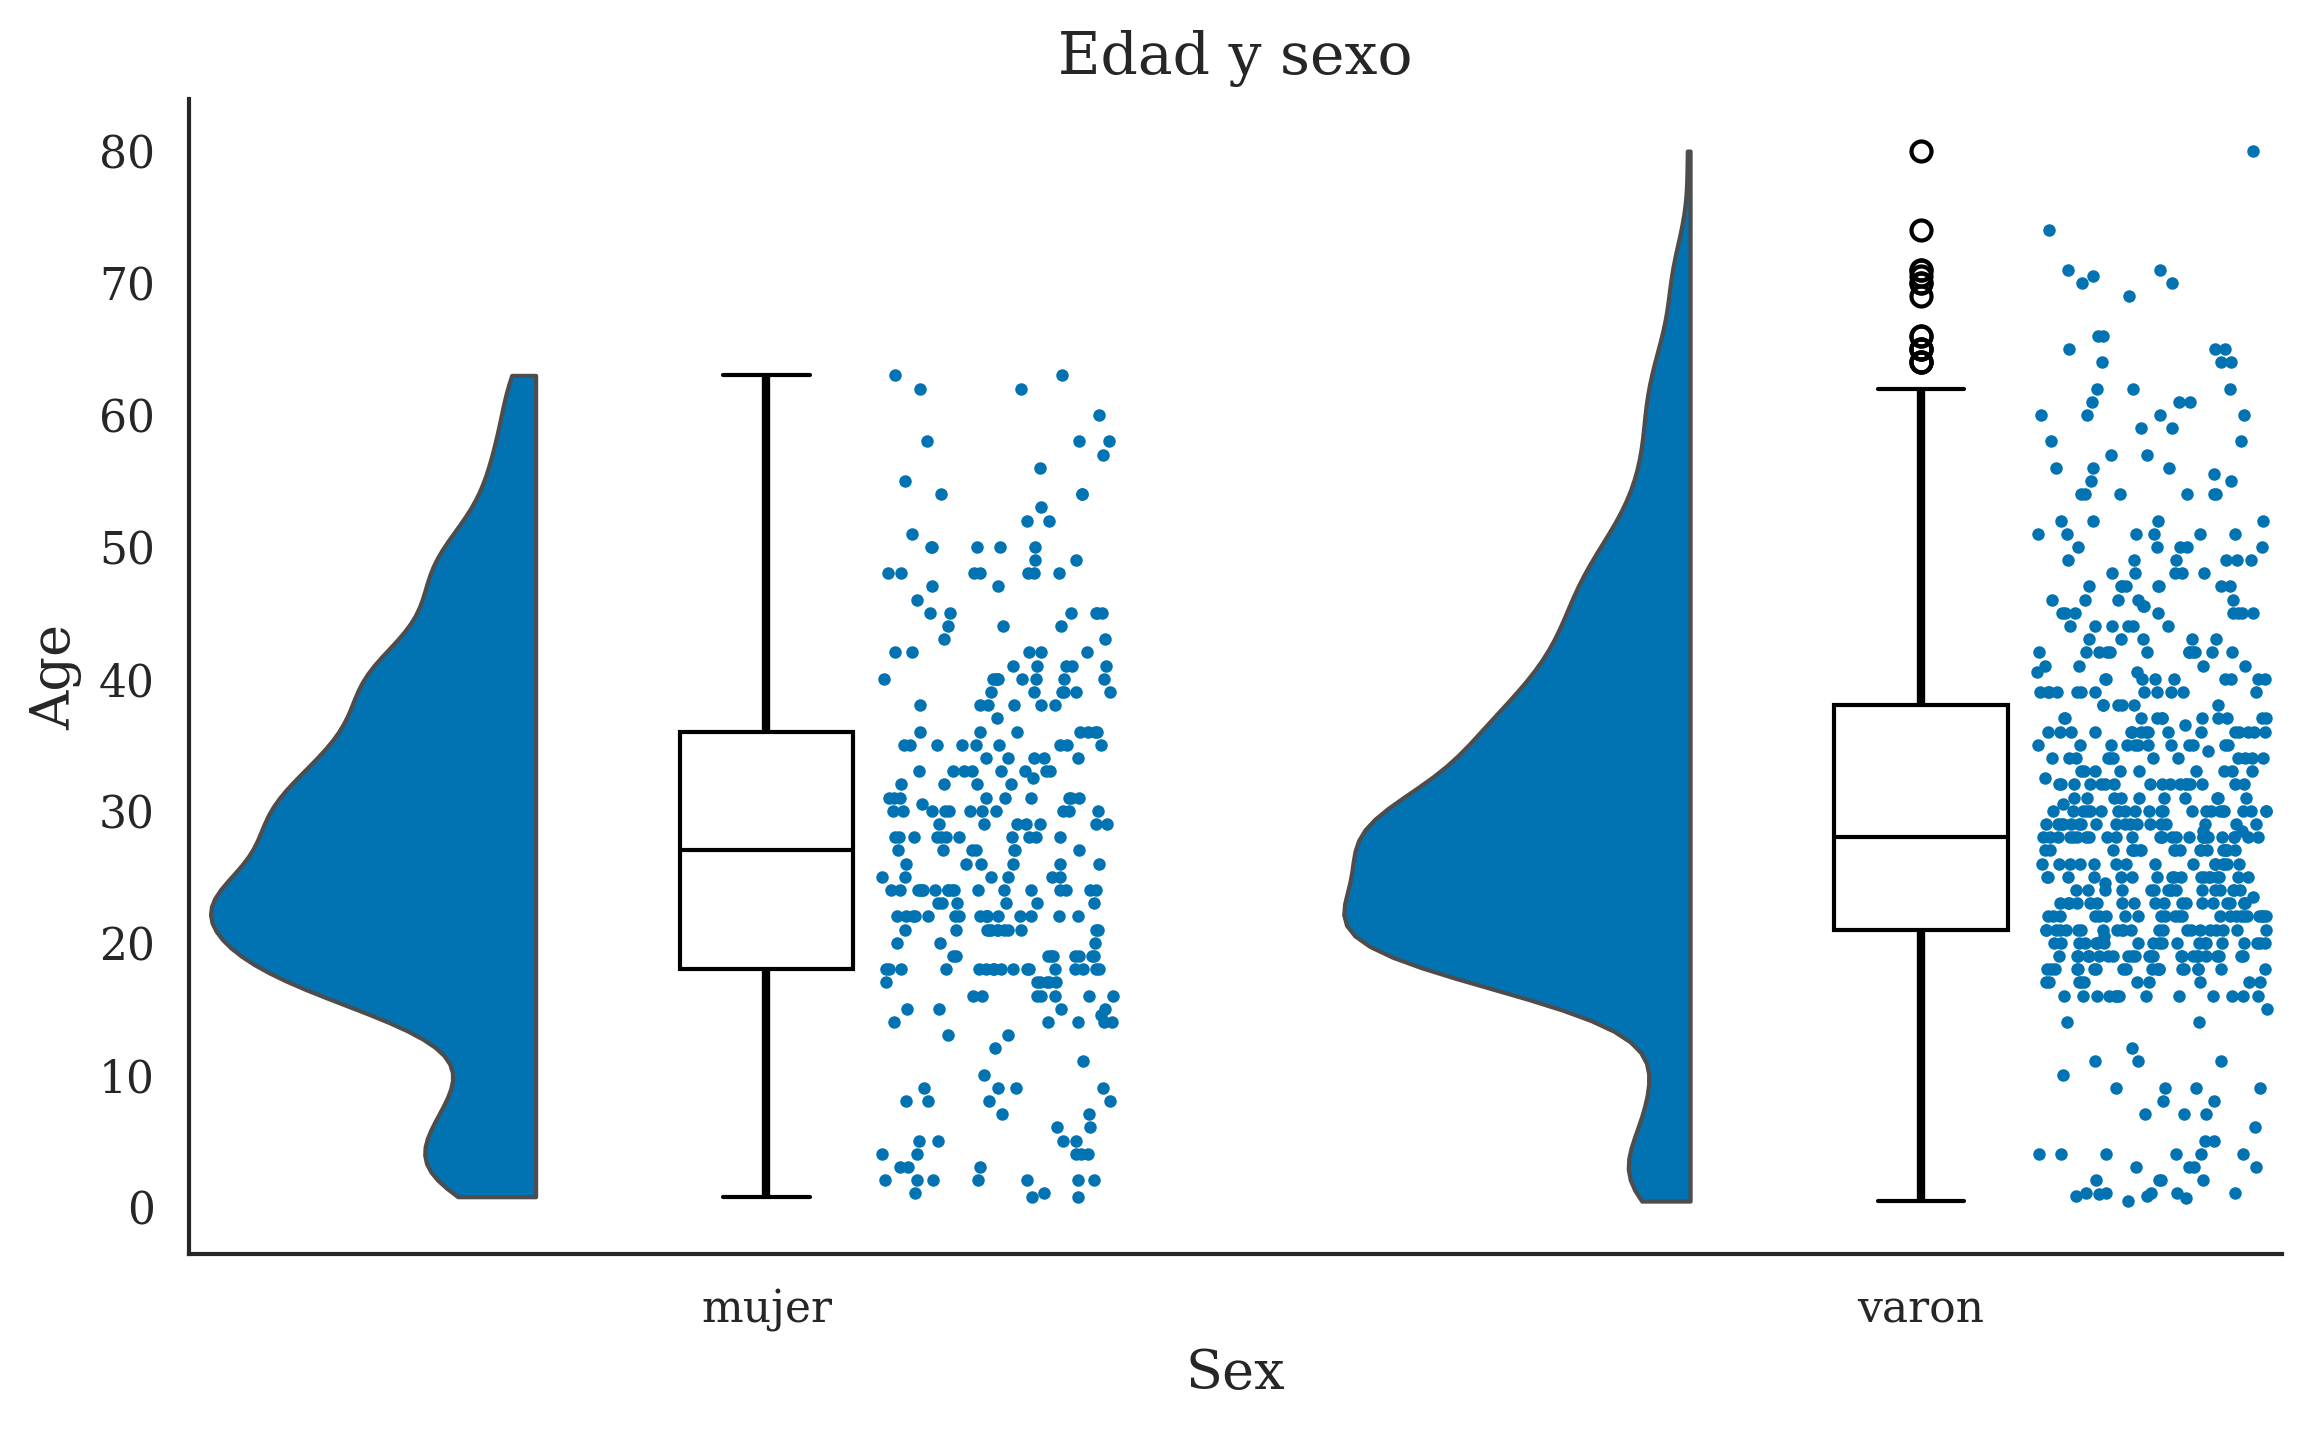

In [82]:
# Nube de lluvia (raincloud plot)
import ptitprince as pt
plt.figure(figsize=(9,5))
ax = pt.RainCloud(data=datos,
    x="Sex",
    y="Age",
    bw=.2,              # suavizado KDE
    width_viol=.6,      # tamaño violín
    width_box=.15,      # caja
    move=.2,            # separación entre elementos
    orient="v")
plt.title("Edad y sexo")
plt.show()

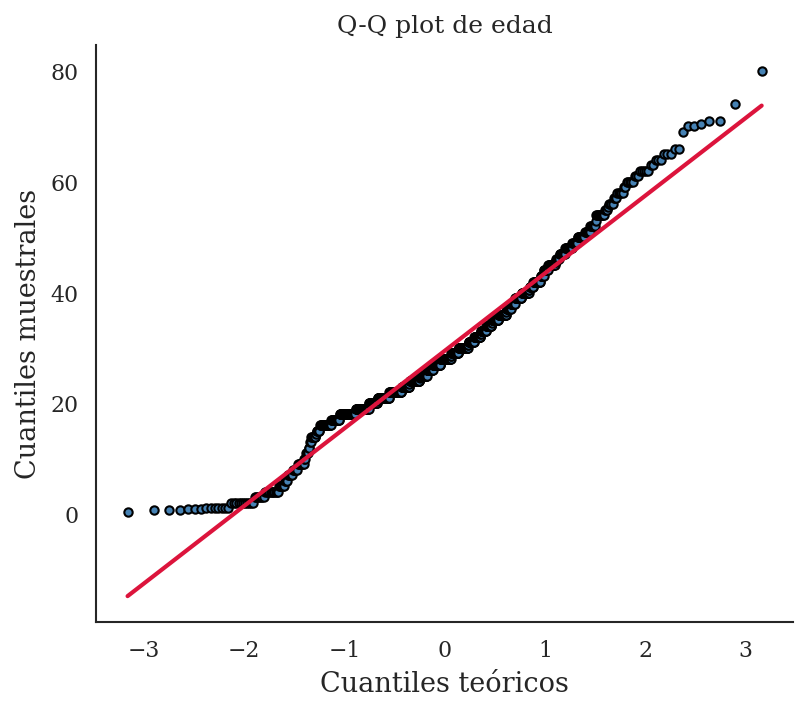

In [83]:
# Normalidad
plt.rcParams["figure.dpi"] = 150
fig, ax = plt.subplots(figsize=(6,5))
# Q-Q plot
stats.probplot(datos["Age"].dropna(), dist="norm", plot=ax)
# Estética
ax.get_lines()[0].set_markerfacecolor("steelblue")
ax.get_lines()[0].set_markeredgecolor("black")
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color("crimson")
ax.get_lines()[1].set_linewidth(2)
ax.set_title("Q-Q plot de edad", fontsize=12)
ax.set_xlabel("Cuantiles teóricos")
ax.set_ylabel("Cuantiles muestrales")
ax.grid(False)
sns.despine()
plt.show()

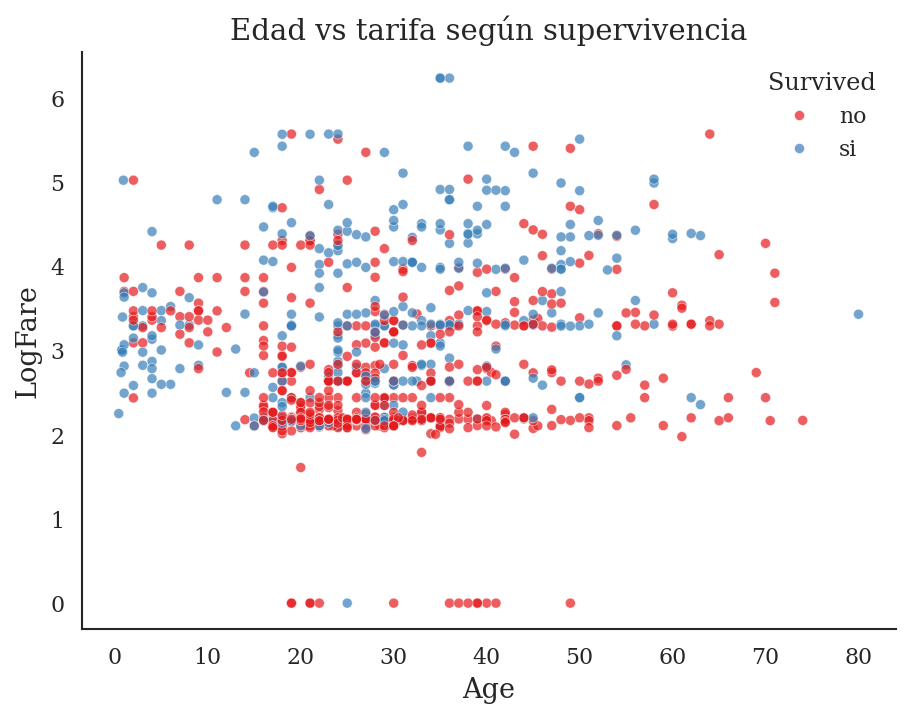

In [84]:
# Dispersión
sns.scatterplot(data=datos,
    x="Age",
    y="LogFare",
    hue="Survived",
    alpha=0.7,
    palette="Set1",
    edgecolor="white",
    linewidth=0.3)
sns.despine()
plt.title("Edad vs tarifa según supervivencia")
plt.show()

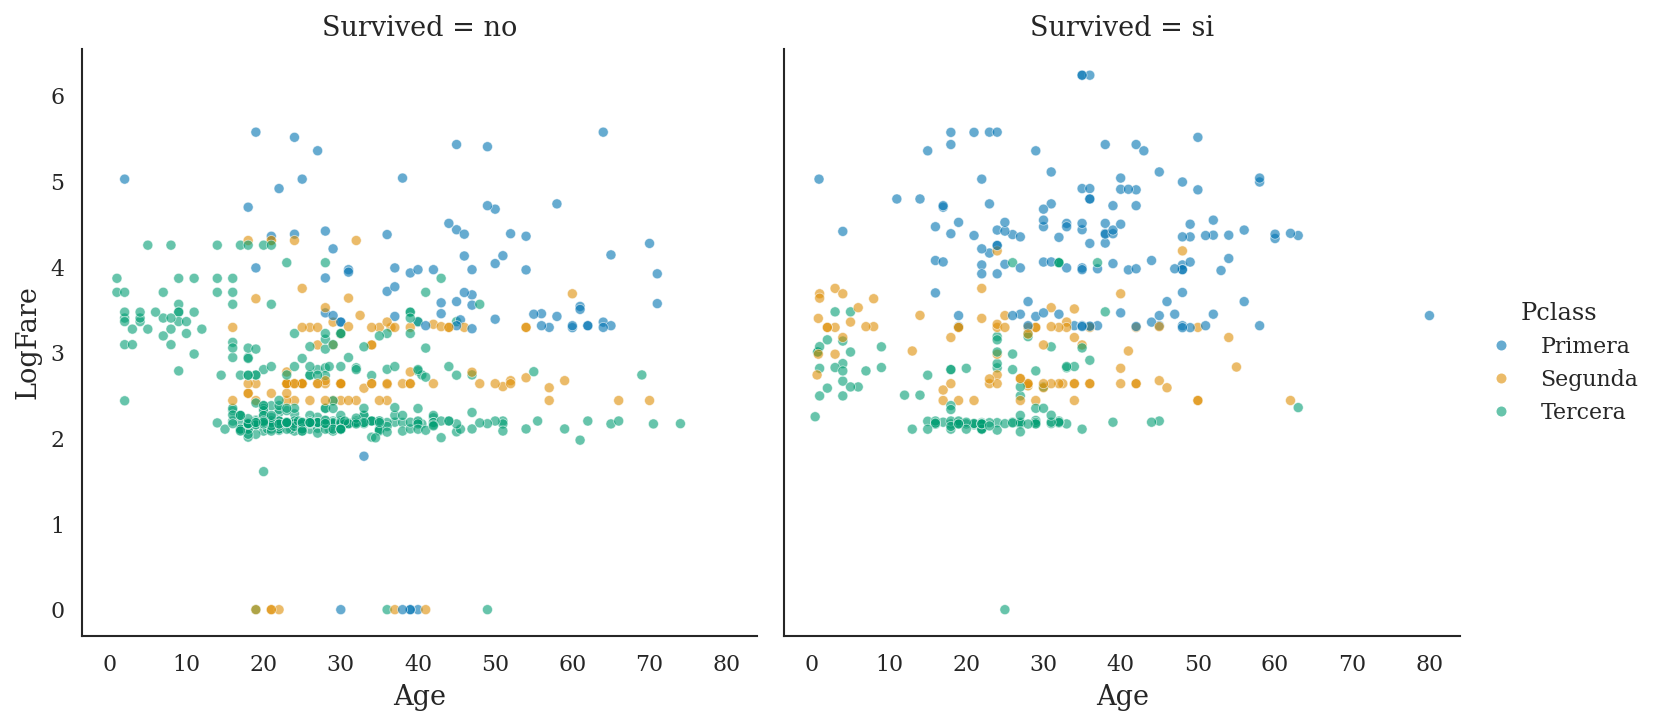

In [85]:
# Dispersión separada
sns.relplot(data=datos,
    x="Age",
    y="LogFare",
    col="Survived",
    hue="Pclass",
    kind="scatter",
    alpha=0.6)

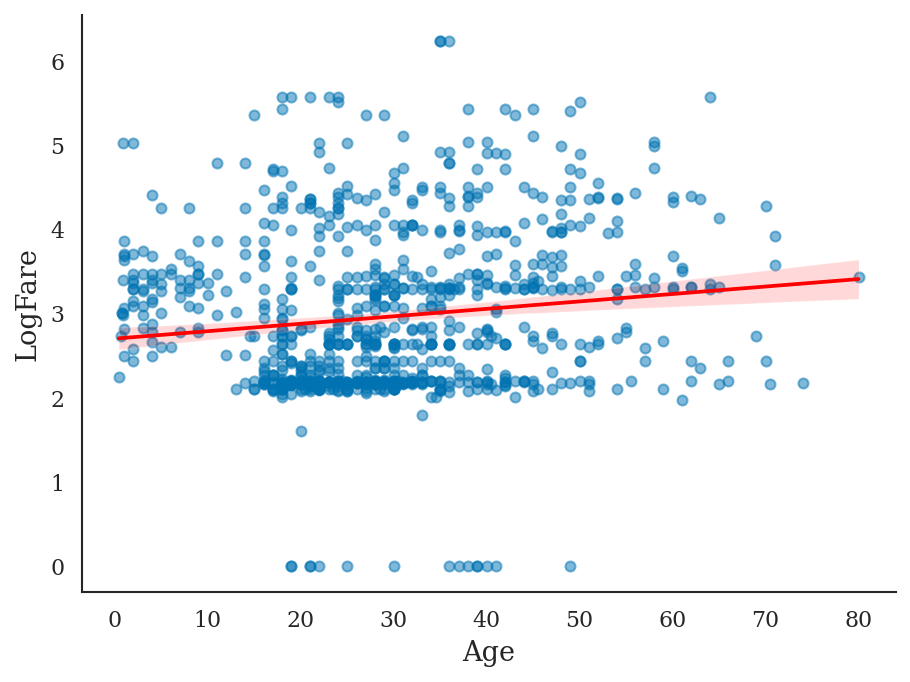

In [86]:
# Dispersión y línea de ajuste
sns.regplot(data=datos,
    x="Age",
    y="LogFare",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"})
sns.despine()

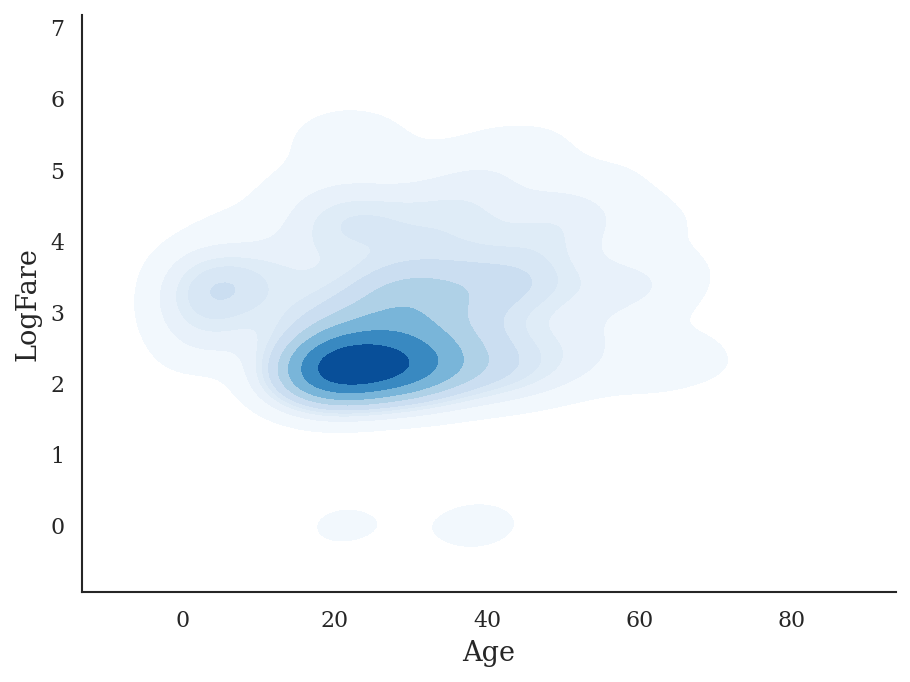

In [88]:
# Densidad de Kernel 2D
sns.kdeplot(data=datos,
    x="Age",
    y="LogFare",
    fill=True,
    cmap="Blues",
    thresh=0.05)
sns.despine()

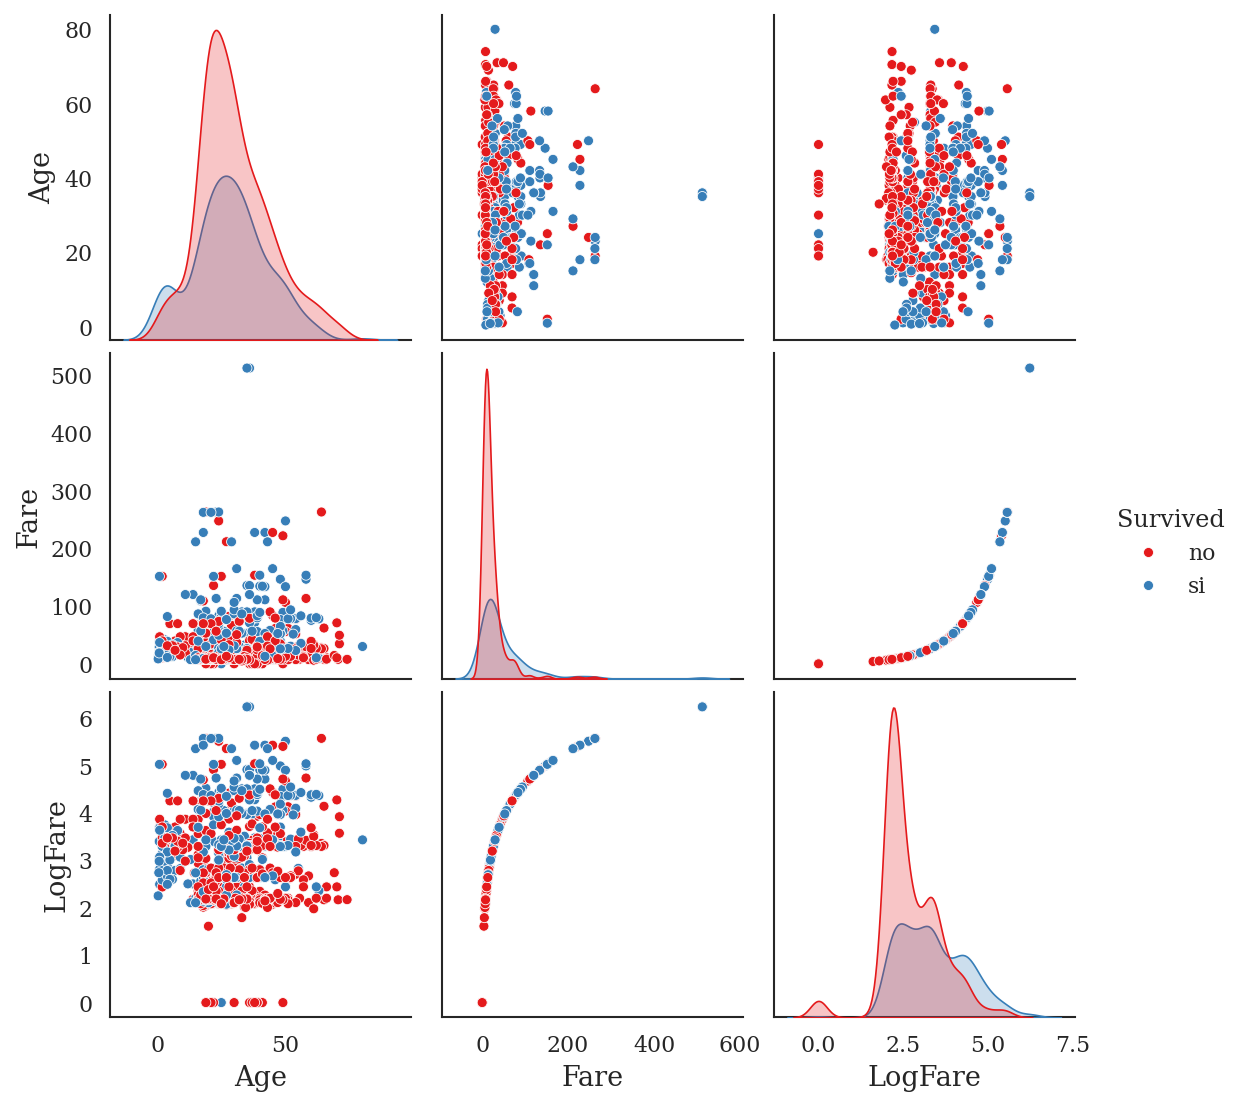

In [90]:
# Pair plot multivariado
sns.pairplot(datos[["Age","Fare","LogFare","Survived"]],
    hue="Survived",
    palette="Set1")

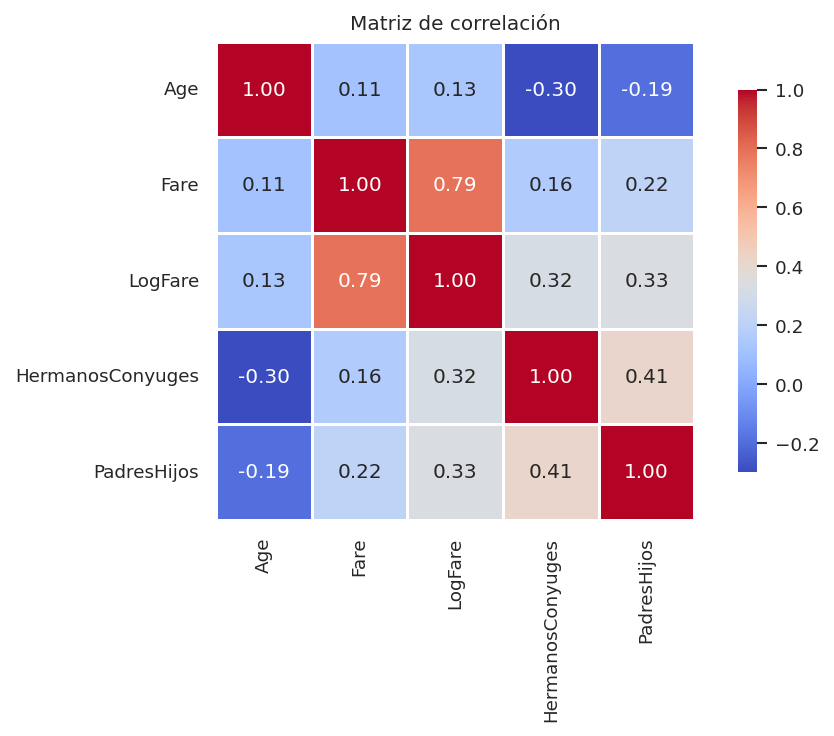

In [95]:
# Matriz de correlaciones
sns.set_theme(style="white", context="paper")
plt.figure(figsize=(7,5), dpi=150)
corr = datos[["Age","Fare","LogFare","HermanosConyuges","PadresHijos"]].corr()
sns.heatmap(corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()